# Đề Tài: Stroke Prediction Dataset — nguồn Kaggle

Bộ dữ liệu này được sử dụng để dự đoán liệu một bệnh nhân có khả năng bị đột quỵ hay không dựa trên các thông số đầu vào như giới tính, tuổi tác, các bệnh lý khác nhau và tình trạng hút thuốc. Mỗi hàng trong dữ liệu cung cấp thông tin liên quan về bệnh nhân.
## Yêu cầu 
1. Chọn 1 dataset và huấn luyện mô hình với dataset đó.
2. Mô hình bao gồm : 1 baseline , 2 model nâng cao hơn.
3. Xây dưng mô mình tự implement và sklearn.  
4. Đánh giá mô hình bằng các tiêu chí accuracy_score , confusion_matrix , roc_auc_score , classification_report
5. So sánh các model và kết luận.
## Task
1. EDA + Preprocessing.
2. Baseline Model — Logistic Regression.
3. **Random Forest Regression** (tự implement và sklearn).
4. **Gradient Boosting Regression** (tự implement)
5. **So sánh** 3 model và kêt luận

## 1. EDA + Preprocessing

### Nền tảng toán học

Toàn bộ dataset được biểu diễn dưới dạng **ma trận đặc trưng**:

$$X \in \mathbb{R}^{n \times p}, \quad y \in \mathbb{R}^n$$

với $n$ là số mẫu, $p$ là số feature. Mỗi hàng $\mathbf{x}_i \in \mathbb{R}^p$ là một vector điểm dữ liệu.

#### Các phép biến đổi trong Preprocessing:

* **StandardScaler**: $x' = \frac{x - \mu}{\sigma}$ — chuẩn hóa về $\mathcal{N}(0, 1)$, tránh feature có scale lớn át feature khác
* **OrdinalEncoder**: ánh xạ thứ tự $\{\text{Low, Medium, High}\} \rightarrow \{0, 1, 2\}$ — giữ cấu trúc thứ tự tuyến tính
* **OneHotEncoder**: ánh xạ $k$ giá trị nominal thành $k$ cột nhị phân trong không gian con trực giao $\{0, 1\}^k$

> **Nguyên tắc quan trọng**: chỉ `fit` trên tập train, rồi `transform` tập test — tránh data leakage (thông tin từ test rò rỉ vào quá trình học).

In [42]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# CHUYỂN ĐỔI SANG MÔ HÌNH PHÂN LOẠI (LOGISTIC REGRESSION)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier 

# Giữ nguyên các công cụ tiền xử lý dữ liệu
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.model_selection import train_test_split

# CHUYỂN ĐỔI METRICS ĐÁNH GIÁ SANG BÀI TOÁN PHÂN LOẠI
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

# Kết nối database
from DB_connect import get_engine

# Gọi hàm lấy engine kết nối SQLite
engine = get_engine()

# 1. Thay đổi câu lệnh SQL để lấy bảng dữ liệu chuẩn 'stroke_table'
df = pd.read_sql("SELECT * FROM stroke_table", con=engine)

# 2. ÉP KIỂU SỐ CHO CÁC CỘT NHỊ PHÂN NGAY TẠI ĐÂY
binary_cols = ['hypertension', 'heart_disease', 'stroke']
for col in binary_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int)

# Hiển thị 5 dòng đầu kiểm tra
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [44]:
df.describe(include='number')

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


Giá trị thiếu:
bmi    201
dtype: int64
Dòng trùng lặp: 0


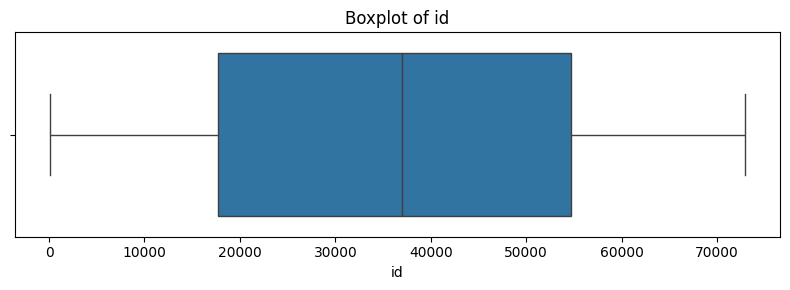

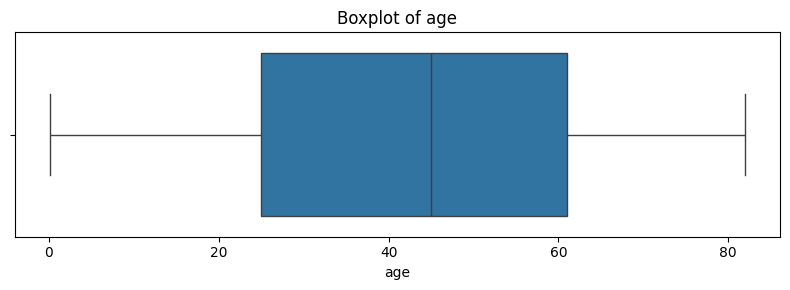

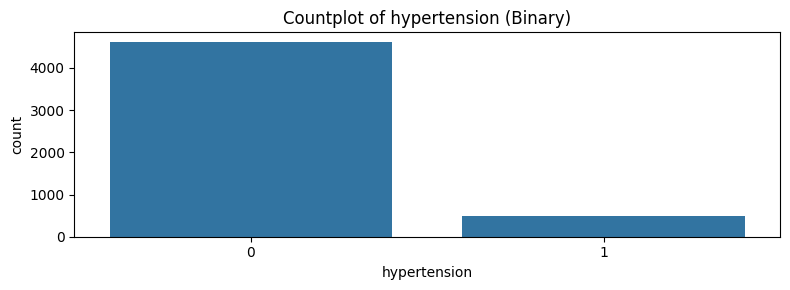

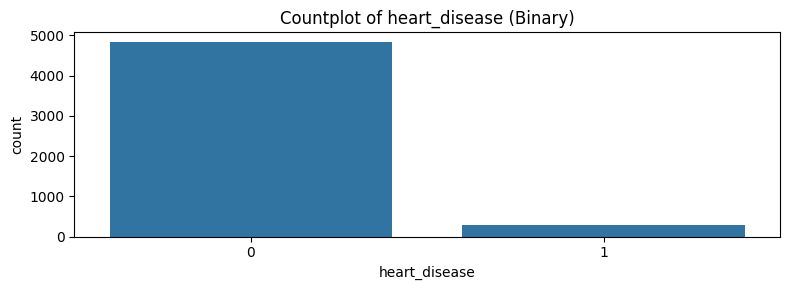

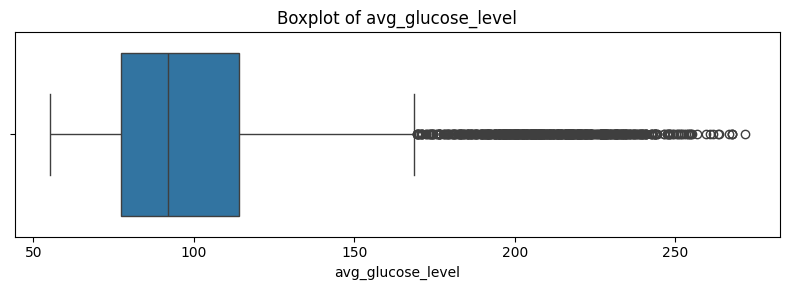

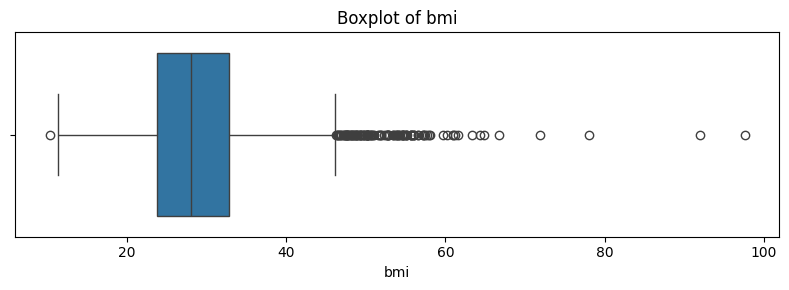

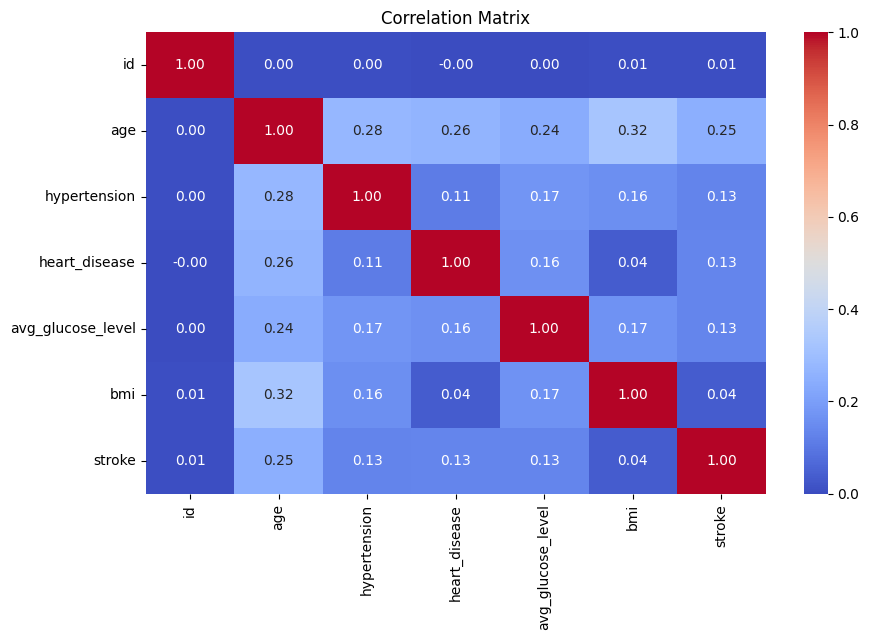


--- KẾT QUẢ ---
Shape train: (4088, 22)
Shape test:  (1022, 22)
Preprocessing hoàn tất thành công!


In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# ── 1. KIỂM TRA
missing_values = df.isnull().sum()
print(f'Giá trị thiếu:\n{missing_values[missing_values > 0]}')
duplicate_rows = df.duplicated().sum()
print(f'Dòng trùng lặp: {duplicate_rows}')
if duplicate_rows > 0:
    df.drop_duplicates(inplace=True)
    df.reset_index(drop=True, inplace=True)

# ── 2. TÁCH CỘT (Giữ nguyên khung của bạn)
num_cols  = df.select_dtypes(include=['number']).columns.tolist()
cate_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
target = 'stroke'
feature_num_cols = [c for c in num_cols if c != target]

nominal_cols = cate_cols

# ── 3. MISSING VALUES
for col in feature_num_cols:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].median())
for col in nominal_cols:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].mode()[0])

# ── 4. VISUALIZE (Đã sửa đổi để tránh lỗi vẽ boxplot cho biến nhị phân)
for col in feature_num_cols:
    plt.figure(figsize=(8, 3))
    
    # Nếu là biến nhị phân (0/1), vẽ countplot để xem phân phối
    if df[col].nunique() <= 2:
        sns.countplot(x=df[col])
        plt.title(f'Countplot of {col} (Binary)')
    # Nếu là biến liên tục (như bmi, avg_glucose_level), vẽ boxplot bình thường
    else:
        sns.boxplot(x=df[col])
        plt.title(f'Boxplot of {col}')
        
    plt.tight_layout()
    plt.show()

# Giữ nguyên phần ma trận tương quan của bạn
corr = df[num_cols].corr()
plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

# ── 5. IQR CLIPPING (Đã sửa đổi điều kiện để bảo vệ cột nhị phân)
for col in feature_num_cols:
    # Chỉ xử lý clipping nếu cột đó có nhiều hơn 2 giá trị riêng biệt (loại trừ 0 và 1)
    if df[col].nunique() > 2:
        Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
        IQR = Q3 - Q1
        df[col] = df[col].clip(Q1 - 1.5*IQR, Q3 + 1.5*IQR)

# ── 6. TRAIN/TEST SPLIT
X = df[feature_num_cols + nominal_cols]
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# ── 7. SCALING
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train[feature_num_cols]), 
                              columns=feature_num_cols, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test[feature_num_cols]), 
                             columns=feature_num_cols, index=X_test.index)

# ── 8. ENCODING
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
if len(nominal_cols) > 0:
    ohe_cols = ohe.fit(X_train[nominal_cols]).get_feature_names_out(nominal_cols)
    ohe_train = pd.DataFrame(ohe.transform(X_train[nominal_cols]), columns=ohe_cols, index=X_train.index)
    ohe_test  = pd.DataFrame(ohe.transform(X_test[nominal_cols]), columns=ohe_cols, index=X_test.index)
    X_train_final = pd.concat([X_train_scaled, ohe_train], axis=1)
    X_test_final  = pd.concat([X_test_scaled,  ohe_test],  axis=1)
else:
    X_train_final = X_train_scaled.copy()
    X_test_final  = X_test_scaled.copy()

feature_names = X_train_final.columns.tolist()

print('\n--- KẾT QUẢ ---')
print('Shape train:', X_train_final.shape)
print('Shape test: ', X_test_final.shape)
print('Preprocessing hoàn tất thành công!')

## 2. Baseline Model — Logistic Regression

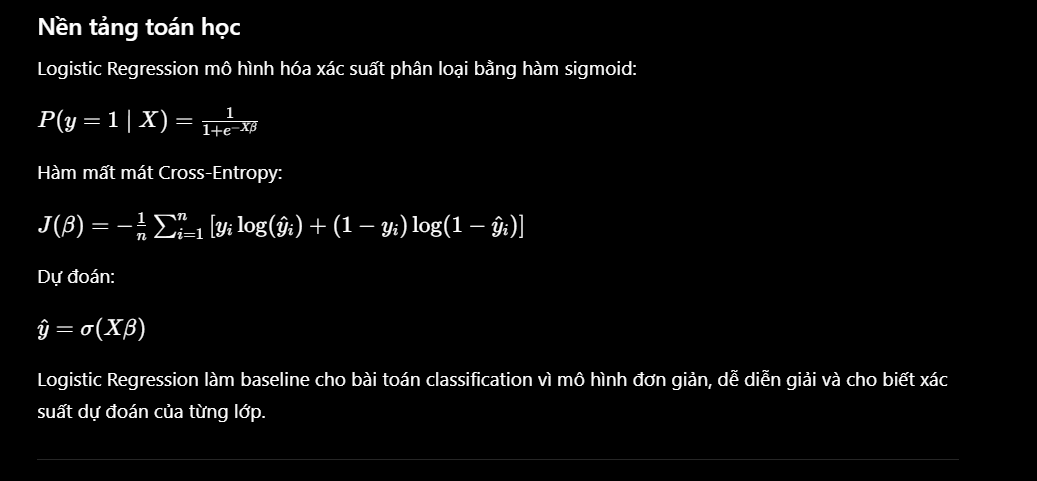
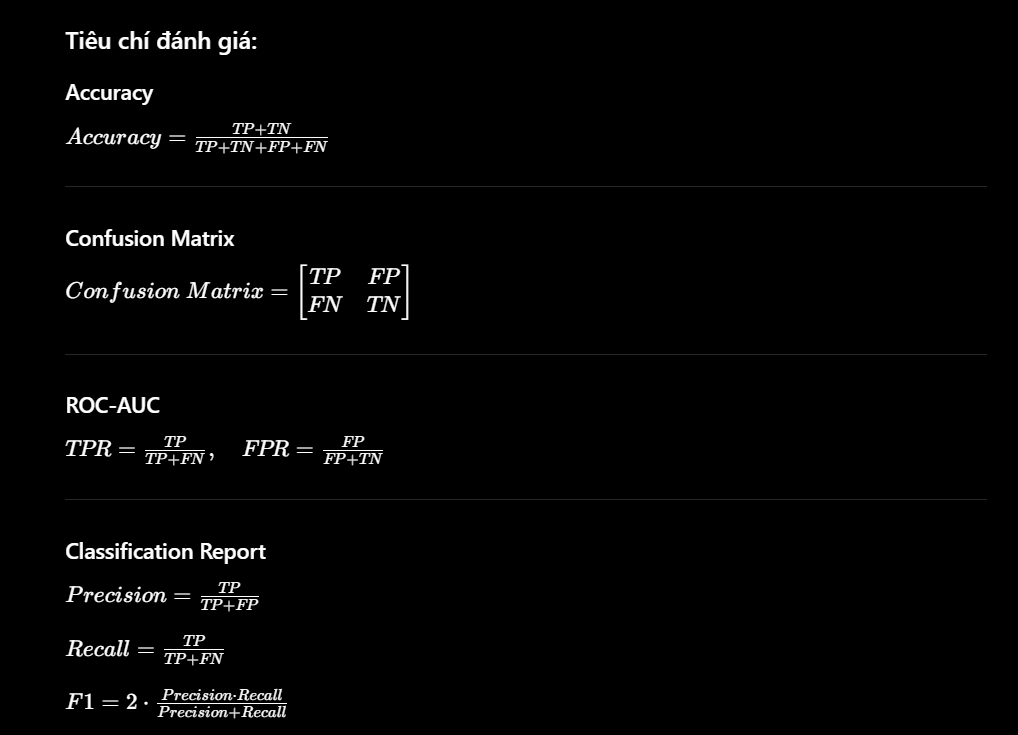

BASELINE - Logistic Regression
Accuracy          : 0.7515
ROC-AUC Score     : 0.8424
Precision (Class 1): 0.1408
Recall (Class 1)   : 0.8000
F1-Score (Class 1) : 0.2395

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.75      0.85       972
           1       0.14      0.80      0.24        50

    accuracy                           0.75      1022
   macro avg       0.56      0.77      0.55      1022
weighted avg       0.95      0.75      0.82      1022



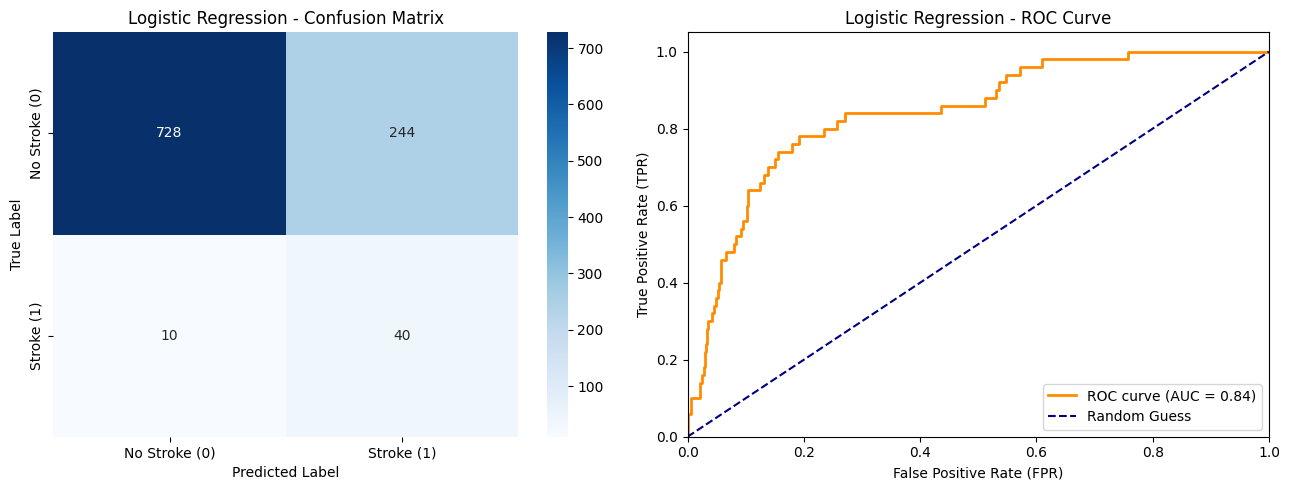

In [46]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve, precision_score, recall_score, f1_score
)

# ── 1. KHỞI TẠO VÀ TRAIN MODEL (ĐÃ THÊM CLASS_WEIGHT ĐỂ CÂN BẰNG)
log_reg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
log_reg.fit(X_train_final, y_train)

# Dự đoán nhãn và xác suất
y_pred_log = log_reg.predict(X_test_final)
y_pred_proba = log_reg.predict_proba(X_test_final)[:, 1]

# ── 2. IN CÁC CHỈ SỐ ĐÁNH GIÁ OUT ĐẦU RA
print('=' * 40)
print('BASELINE - Logistic Regression')
print('=' * 40)
print(f'Accuracy          : {accuracy_score(y_test, y_pred_log):.4f}')
print(f'ROC-AUC Score     : {roc_auc_score(y_test, y_pred_proba):.4f}')
print(f'Precision (Class 1): {precision_score(y_test, y_pred_log, zero_division=0):.4f}')
print(f'Recall (Class 1)   : {recall_score(y_test, y_pred_log, zero_division=0):.4f}')
print(f'F1-Score (Class 1) : {f1_score(y_test, y_pred_log, zero_division=0):.4f}')

print('\nDetailed Classification Report:')
print(classification_report(y_test, y_pred_log, zero_division=0))

# ── 3. VẼ BIỂU ĐỒ CONFUSION MATRIX & ROC CURVE
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Đồ thị bên trái: Confusion Matrix
cm = confusion_matrix(y_test, y_pred_log)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Stroke (0)', 'Stroke (1)'],
            yticklabels=['No Stroke (0)', 'Stroke (1)'])
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')
axes[0].set_title('Logistic Regression - Confusion Matrix')

# Đồ thị bên phải: ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc_score(y_test, y_pred_proba):.2f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--', label='Random Guess')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate (FPR)')
axes[1].set_ylabel('True Positive Rate (TPR)')
axes[1].set_title('Logistic Regression - ROC Curve')
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

## 3. **Random Forest Regression** (tự implement và sklearn).
### 3.1. Random Forest Regression (implement)
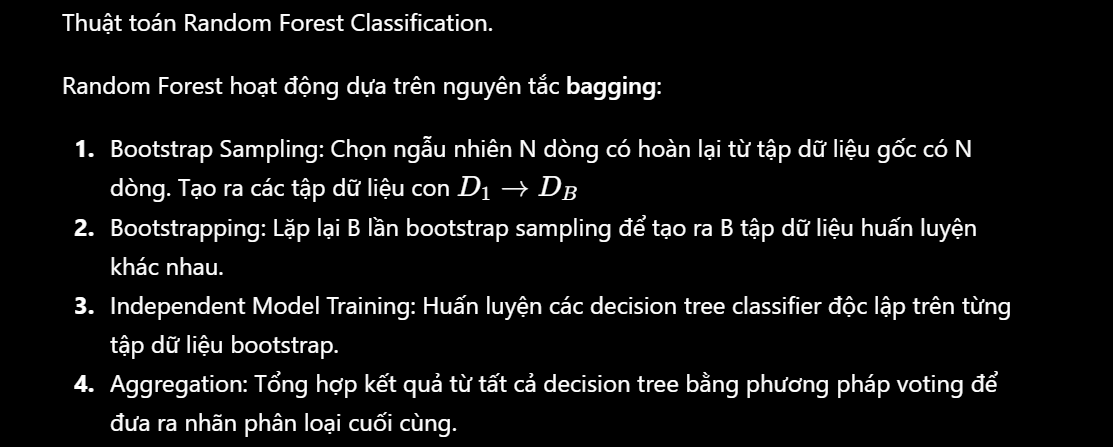
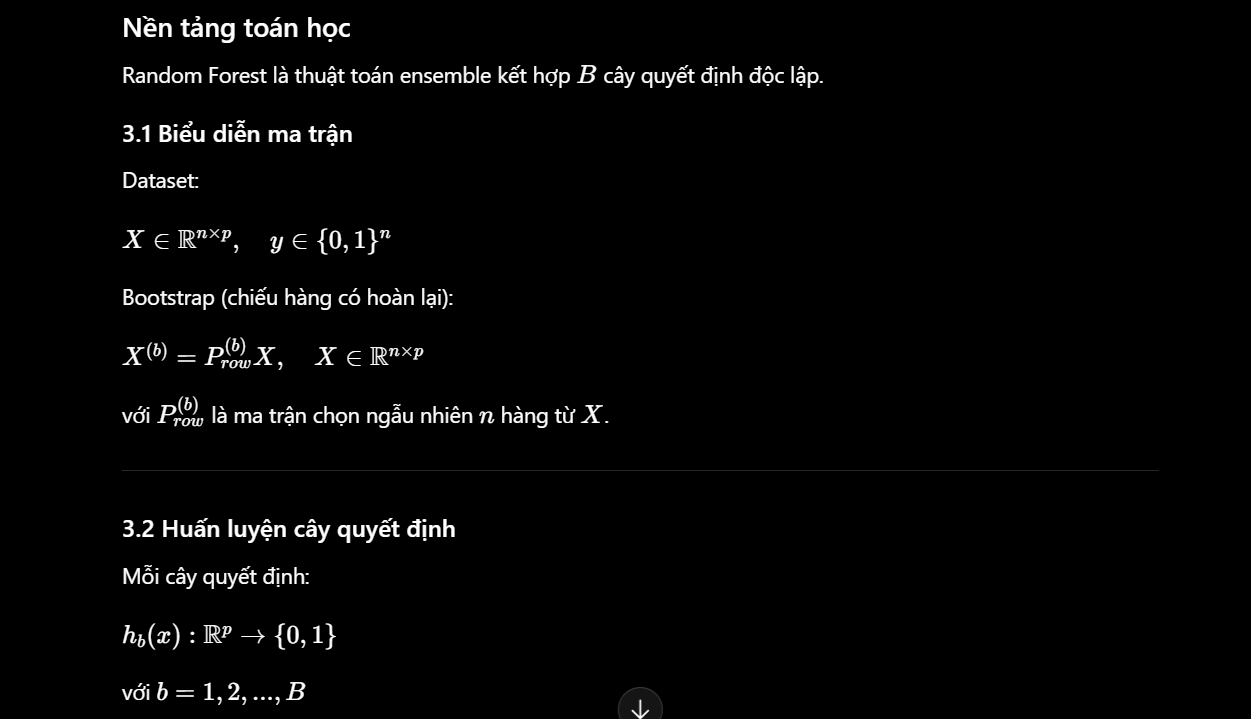
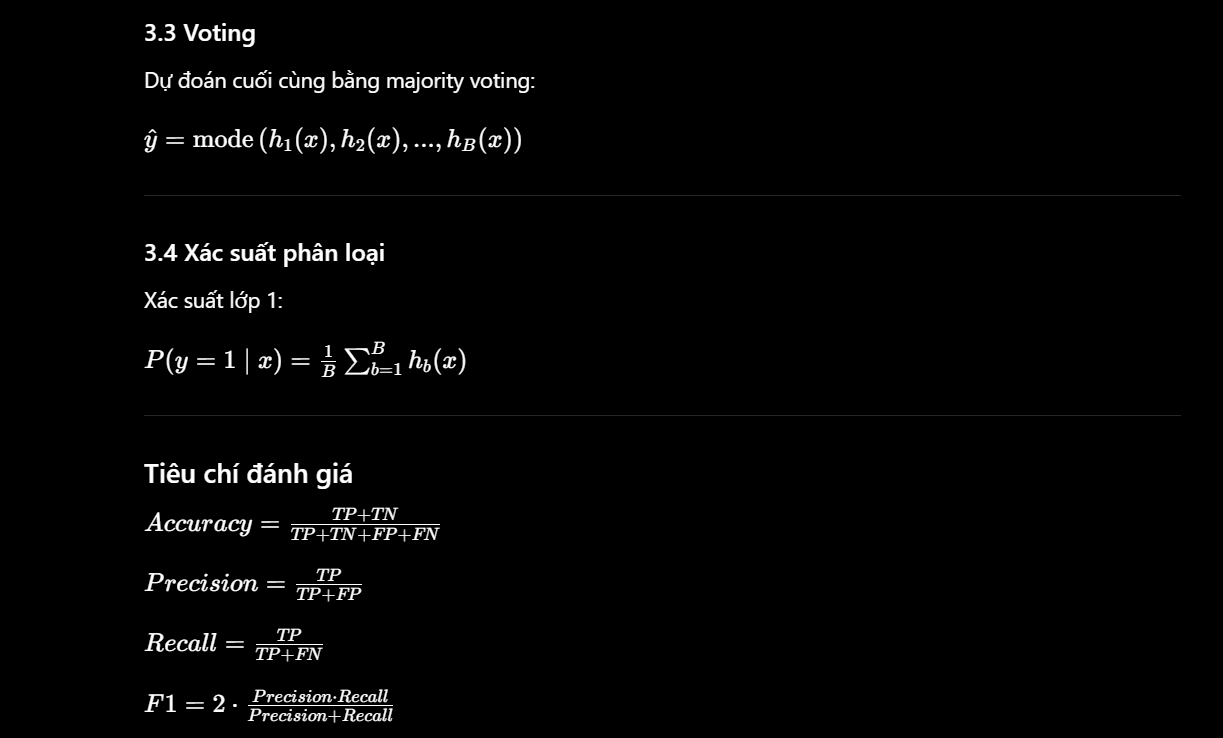

In [47]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve, precision_score, recall_score, f1_score
)

# ─── 1. ĐỊNH NGHĨA LỚP NODE CHO CÂY PHÂN LOẠI ───
class Node:
    def __init__(self):
        self.feature_index = None   # Cột dữ liệu được chọn để chia
        self.threshold = None       # Ngưỡng chia cắt
        self.left = None            # Nhánh con bên trái (<= threshold)
        self.right = None           # Nhánh con bên phải (> threshold)
        self.value = None           # Nếu là nút lá: Lưu nhãn dự đoán lớp (0 hoặc 1)

# ─── 2. ĐỊNH NGHĨA HÀM TÍNH GINI IMPURITY (THAY CHO VARIANCE REDUCTION) ───
def calculate_gini(y):
    """
    Tính chỉ số Gini Impurity của một tập nhãn y.
    Gini càng nhỏ thì tập dữ liệu càng thuần nhất (ít bị tạp chất).
    """
    n = len(y)
    if n == 0:
        return 0.0
    
    # Đếm số lượng xuất hiện của từng lớp (0 và 1)
    counts = np.bincount(y)
    probabilities = counts / n
    return 1.0 - np.sum(probabilities ** 2)

def gini_gain(y, y_left, y_right):
    """
    Tính mức độ suy giảm chỉ số Gini (Information Gain) sau khi chia nhánh.
    Mục tiêu: Tìm điểm chia cắt sao cho Gain này lớn nhất.
    """
    n = len(y)
    n_l = len(y_left)
    n_r = len(y_right)
    
    # Nếu một trong hai nhánh không có phần tử nào, Gain bằng 0
    if n_l == 0 or n_r == 0:
        return 0.0
        
    current_gini = calculate_gini(y)
    weighted_gini = (n_l / n) * calculate_gini(y_left) + (n_r / n) * calculate_gini(y_right)
    return current_gini - weighted_gini

# ─── 3. HÀM TÌM ĐIỂM CHIA TỐT NHẤT (BEST SPLIT) ───
def best_split(X, y, n_features_to_try):
    n_samples, n_features = X.shape
    best_gain = -np.inf
    best_feature = None
    best_threshold = None
    
    # Feature Subsampling: Chọn ngẫu nhiên m thuộc tính tại mỗi node
    feature_indices = np.random.choice(
        n_features, size=min(n_features_to_try, n_features), replace=False
    )
    
    for j in feature_indices:
        col = X[:, j]
        thresholds = np.unique(col)
        
        for t in thresholds:
            left_mask = col <= t
            right_mask = ~left_mask
            
            if left_mask.sum() == 0 or right_mask.sum() == 0:
                continue
                
            # Tính toán độ lợi Gini cho điểm cắt hiện tại
            gain = gini_gain(y, y[left_mask], y[right_mask])
            
            if gain > best_gain:
                best_gain = gain
                best_feature = j
                best_threshold = t
                
    return best_feature, best_threshold

# ─── 4. LỚP CÂY QUYẾT ĐỊNH PHÂN LOẠI (DECISION TREE CLASSIFIER) ───
class DecisionTreeClassifierBuild:
    def __init__(self, max_depth=None, min_samples_split=2, n_features=None):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.n_features = n_features
        self.root = None

    def fit(self, X, y):
        n_features_to_try = self.n_features if self.n_features is not None else X.shape[1]
        self.root = self._build(X, y, depth=0, n_features_to_try=n_features_to_try)
        return self

    def _build(self, X, y, depth, n_features_to_try):
        node = Node()
        
        # Điều kiện dừng để tạo nút lá
        stop = (
            len(y) < self.min_samples_split or 
            (self.max_depth is not None and depth >= self.max_depth) or 
            len(np.unique(y)) == 1
        )
        
        if stop:
            # Ghi nhận nhãn số đông tại nút lá (Dùng cơ chế bỏ phiếu)
            node.value = Counter(y).most_common(1)[0][0]
            return node

        feat, thresh = best_split(X, y, n_features_to_try)
        if feat is None:
            node.value = Counter(y).most_common(1)[0][0]
            return node

        mask = X[:, feat] <= thresh
        node.feature_index = feat
        node.threshold = thresh
        
        # Đệ quy xây dựng nhánh trái và nhánh phải
        node.left = self._build(X[mask], y[mask], depth + 1, n_features_to_try)
        node.right = self._build(X[~mask], y[~mask], depth + 1, n_features_to_try)
        return node

    def predict_one(self, x, node=None):
        if node is None:
            node = self.root
        if node.value is not None:
            return node.value
        if x[node.feature_index] <= node.threshold:
            return self.predict_one(x, node.left)
        return self.predict_one(x, node.right)

    def predict(self, X):
        return np.array([self.predict_one(x) for x in X])

# ─── 5. LỚP RANDOM FOREST CLASSIFIER BUILD (TỔ HỢP CÁC CÂY PHÂN LOẠI) ───
class RandomForestClassifierBuild:
    def __init__(self, n_estimators=100, max_depth=None, min_samples_split=2, max_features='sqrt'):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.max_features = max_features
        self.trees = []

    def _n_features_to_try(self, p):
        if self.max_features == 'sqrt': return max(1, int(np.sqrt(p)))
        if self.max_features == 'log2': return max(1, int(np.log2(p)))
        if isinstance(self.max_features, int): return self.max_features
        return p

    def fit(self, X, y):
        n, p = X.shape
        m = self._n_features_to_try(p)
        self.trees = []
        
        for _ in range(self.n_estimators):
            # Bootstrap sampling: Lấy mẫu ngẫu nhiên có lặp lại n dòng từ tập gốc
            idx = np.random.choice(n, size=n, replace=True)
            X_boot, y_boot = X[idx], y[idx]
            
            tree = DecisionTreeClassifierBuild(
                max_depth=self.max_depth,
                min_samples_split=self.min_samples_split,
                n_features=m
            )
            tree.fit(X_boot, y_boot)
            self.trees.append(tree)
        return self

    def predict(self, X):
        # Thu thập các dự đoán từ tất cả các cây trong rừng độc lập (Ma trận dạng B x n_samples)
        tree_preds = np.array([t.predict(X) for t in self.trees])
        
        # Thực hiện bầu chọn số đông (Majority Voting) theo từng cột mẫu dữ liệu
        final_preds = []
        for i in range(X.shape[0]):
            sample_preds = tree_preds[:, i]
            majority_vote = Counter(sample_preds).most_common(1)[0][0]
            final_preds.append(majority_vote)
            
        return np.array(final_preds)

    def predict_proba(self, X):
        """
        Tính xác suất thuộc về lớp 1 (Bị đột quỵ) bằng tỷ lệ số cây dự đoán lớp 1.
        Hàm này rất quan trọng để vẽ biểu đồ ROC Curve và tính chỉ số ROC-AUC.
        """
        tree_preds = np.array([t.predict(X) for t in self.trees]) # B x n_samples
        # Tính tỷ lệ số cây bỏ phiếu 1 trên tổng số cây (n_estimators) cho từng mẫu
        proba_class_1 = np.mean(tree_preds == 1, axis=0)
        return proba_class_1

IMPLEMENT - Random Forest Classifier
Accuracy          : 0.9511
ROC-AUC Score     : 0.7521
Precision (Class 1): 0.0000
Recall (Class 1)   : 0.0000
F1-Score (Class 1) : 0.0000

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       972
           1       0.00      0.00      0.00        50

    accuracy                           0.95      1022
   macro avg       0.48      0.50      0.49      1022
weighted avg       0.90      0.95      0.93      1022



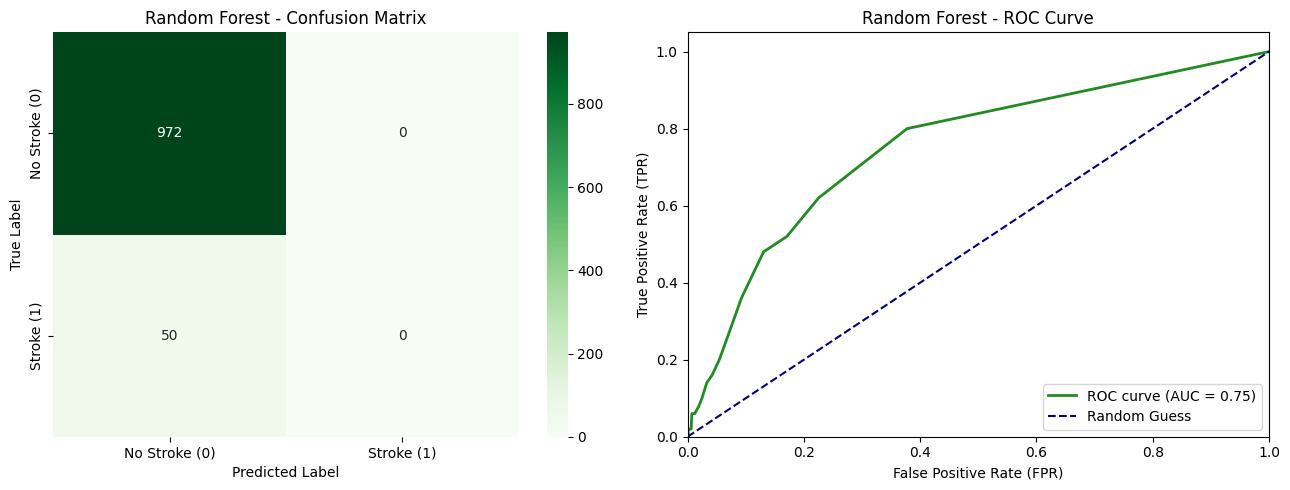

In [48]:
# Khởi tạo mô hình rừng phân loại tự xây dựng
# Tham số cấu hình tùy chỉnh để tránh phân tách quá sâu (overfitting)
RFC = RandomForestClassifierBuild(n_estimators=50, max_depth=10, min_samples_split=5, max_features='sqrt')

# Tiến hành huấn luyện (Sử dụng dữ liệu mảng numpy thông qua .values)
RFC.fit(X_train_final.values, y_train.values)

# Thực hiện dự đoán nhãn lớp và xác suất lớp đột quỵ (Class 1)
y_pred_rf = RFC.predict(X_test_final.values)
y_pred_proba_rf = RFC.predict_proba(X_test_final.values)

# ─── IN ĐẦU RA CÁC TIÊU CHÍ ĐÁNH GIÁ PHÂN LOẠI ĐỘT QUỴ ───
print('=' * 40)
print('IMPLEMENT - Random Forest Classifier')
print('=' * 40)
print(f'Accuracy          : {accuracy_score(y_test, y_pred_rf):.4f}')
print(f'ROC-AUC Score     : {roc_auc_score(y_test, y_pred_proba_rf):.4f}')
print(f'Precision (Class 1): {precision_score(y_test, y_pred_rf, zero_division=0):.4f}')
print(f'Recall (Class 1)   : {recall_score(y_test, y_pred_rf, zero_division=0):.4f}')
print(f'F1-Score (Class 1) : {f1_score(y_test, y_pred_rf, zero_division=0):.4f}')

print('\nDetailed Classification Report:')
print(classification_report(y_test, y_pred_rf, zero_division=0))

# ─── VẼ BIỂU ĐỒ CONFUSION MATRIX & ROC CURVE CHO RANDOM FOREST ───
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Đồ thị bên trái: Confusion Matrix (Ma trận nhầm lẫn)
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[0],
            xticklabels=['No Stroke (0)', 'Stroke (1)'],
            yticklabels=['No Stroke (0)', 'Stroke (1)'])
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')
axes[0].set_title('Random Forest - Confusion Matrix')

# Đồ thị bên phải: ROC Curve (Đường cong ROC)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)
axes[1].plot(fpr_rf, tpr_rf, color='forestgreen', lw=2, label=f'ROC curve (AUC = {roc_auc_score(y_test, y_pred_proba_rf):.2f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--', label='Random Guess')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate (FPR)')
axes[1].set_ylabel('True Positive Rate (TPR)')
axes[1].set_title('Random Forest - ROC Curve')
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

### 3.2. Feature Selection dựa trên Feature Importance
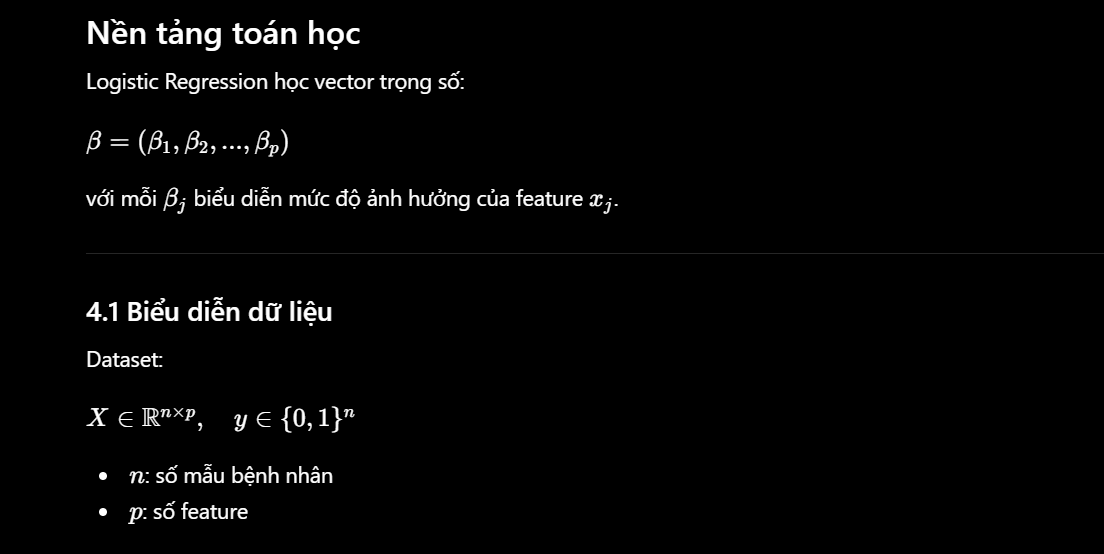
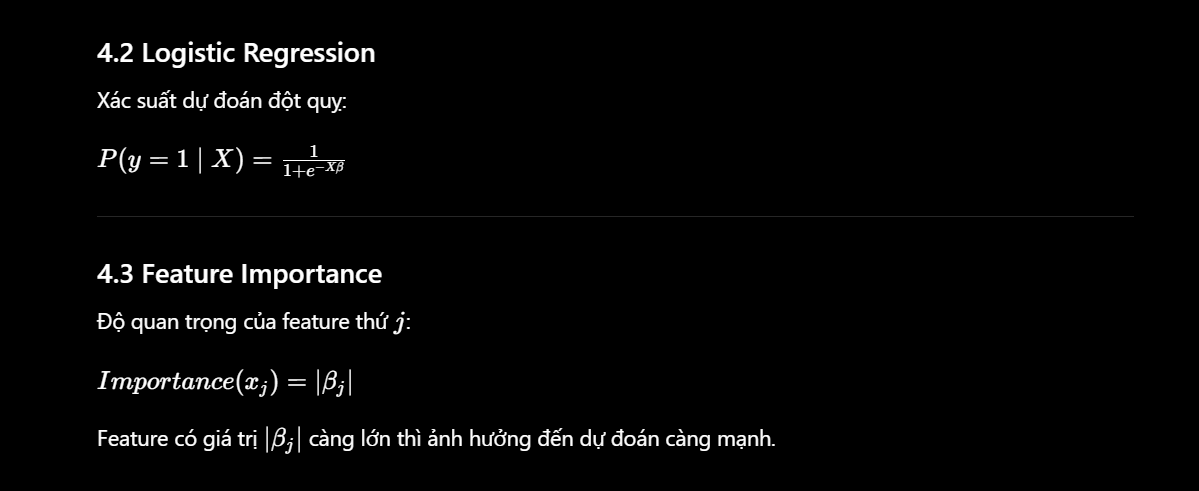
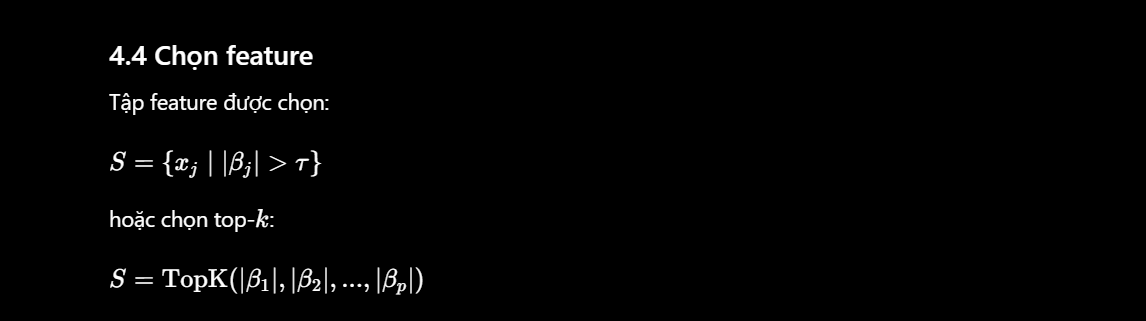

--- BẢNG XẾP HẠNG FEATURE IMPORTANCE ---
                           Feature  Importance
0                              age    0.140395
1                               id    0.138464
2                              bmi    0.137572
3                avg_glucose_level    0.111128
4             Residence_type_Urban    0.036844
5                      gender_Male    0.036547
6                work_type_Private    0.036102
7          work_type_Self-employed    0.035804
8      smoking_status_never smoked    0.035656
9                    gender_Female    0.035062
10                    hypertension    0.034022
11            Residence_type_Rural    0.033873
12  smoking_status_formerly smoked    0.031050
13          smoking_status_Unknown    0.030753
14                   heart_disease    0.030159
15              work_type_Govt_job    0.028376
16           smoking_status_smokes    0.027039
17                ever_married_Yes    0.019759
18                 ever_married_No    0.015897
19              wor

C:\Users\dell\AppData\Local\Temp\ipykernel_22132\3627087130.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


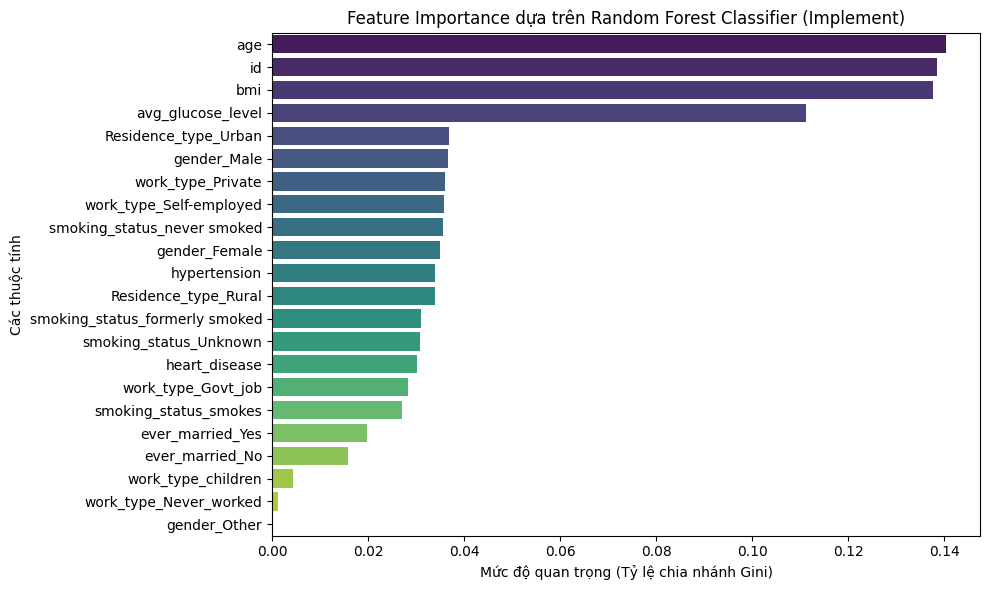


👉 Các đặc trưng được lựa chọn để đưa vào mô hình tối ưu: ['age', 'id', 'bmi', 'avg_glucose_level', 'Residence_type_Urban']


In [49]:
# ─── 1. HÀM TÍNH FEATURE IMPORTANCE TỪ MÔ HÌNH RANDOM FOREST TỰ XÂY DỰNG ───
def get_rf_feature_importance(rf_model, feature_names):
    """
    Tính toán tầm quan trọng của thuộc tính dựa trên số lần thuộc tính đó 
    được chọn làm điểm chia tốt nhất (Best Split) trên toàn bộ rừng cây.
    """
    importance_counts = np.zeros(len(feature_names))
    
    # Hàm đệ quy duyệt qua các node trong cây quyết định
    def traverse_node(node):
        if node is None or node.value is not None:
            return
        if node.feature_index is not None:
            # Cộng điểm cho thuộc tính đóng vai trò chia nhánh tại node này
            importance_counts[node.feature_index] += 1
        traverse_node(node.left)
        traverse_node(node.right)

    # Duyệt qua từng cây độc lập trong Random Forest
    for tree in rf_model.trees:
        traverse_node(tree.root)
        
    # Chuẩn hóa về dạng tỷ lệ phần trăm [0, 1]
    total_splits = np.sum(importance_counts)
    if total_splits > 0:
        importances = importance_counts / total_splits
    else:
        importances = importance_counts
        
    return importances

# ─── 2. TÍNH TOÁN VÀ SẮP XẾP TẦM QUAN TRỌNG ĐẶC TRƯNG ───
importances = get_rf_feature_importance(RFC, feature_names)

# Tạo DataFrame lưu trữ kết quả để dễ xử lý
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

print("--- BẢNG XẾP HẠNG FEATURE IMPORTANCE ---")
print(importance_df)

# ─── 3. VẼ BIỂU ĐỒ FEATURE IMPORTANCE (SỬA ĐỔI CHO BÀI TOÁN ĐỘT QUỴ) ───
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('Feature Importance dựa trên Random Forest Classifier (Implement)')
plt.xlabel('Mức độ quan trọng (Tỷ lệ chia nhánh Gini)')
plt.ylabel('Các thuộc tính')
plt.tight_layout()
plt.show()

# ─── 4. TRÍCH CHỌN ĐẶC TRƯNG (FEATURE SELECTION) ───
# Giữ lại Top N đặc trưng quan trọng nhất (Ví dụ: Giữ lại Top 5 đặc trưng hàng đầu)
top_n = 5 
selected_features = importance_df['Feature'].head(top_n).tolist()
print(f"\n👉 Các đặc trưng được lựa chọn để đưa vào mô hình tối ưu: {selected_features}")

# Tiến hành lọc lại ma trận dữ liệu chỉ giữ lại các cột thuộc tính được chọn
X_train_selected = X_train_final[selected_features]
X_test_selected  = X_test_final[selected_features]

LOGISTIC REGRESSION (Sau khi chọn lọc Top 5 Features)
Accuracy          : 0.7427
ROC-AUC Score     : 0.8375
Precision (Class 1): 0.1365
Recall (Class 1)   : 0.8000
F1-Score (Class 1) : 0.2332

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.74      0.85       972
           1       0.14      0.80      0.23        50

    accuracy                           0.74      1022
   macro avg       0.56      0.77      0.54      1022
weighted avg       0.94      0.74      0.82      1022



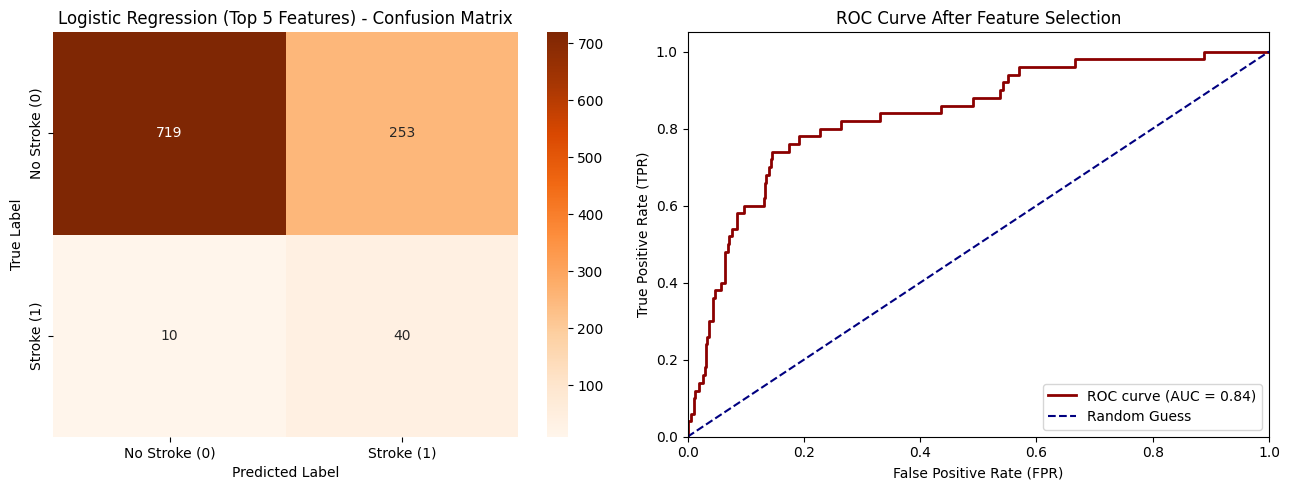

In [50]:
# ─── 5. HUẤN LUYỆN LẠI LOGISTIC REGRESSION VỚI DỮ LIỆU ĐÃ QUA LỌC ───
log_reg_selected = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
log_reg_selected.fit(X_train_selected, y_train)

# Dự đoán đầu ra
y_pred_selected = log_reg_selected.predict(X_test_selected)
y_pred_proba_selected = log_reg_selected.predict_proba(X_test_selected)[:, 1]

# ─── 6. XUẤT CÁC TIÊU CHÍ ĐÁNH GIÁ SAU FEATURE SELECTION ───
print('=' * 50)
print(f'LOGISTIC REGRESSION (Sau khi chọn lọc Top {top_n} Features)')
print('=' * 50)
print(f'Accuracy          : {accuracy_score(y_test, y_pred_selected):.4f}')
print(f'ROC-AUC Score     : {roc_auc_score(y_test, y_pred_proba_selected):.4f}')
print(f'Precision (Class 1): {precision_score(y_test, y_pred_selected, zero_division=0):.4f}')
print(f'Recall (Class 1)   : {recall_score(y_test, y_pred_selected, zero_division=0):.4f}')
print(f'F1-Score (Class 1) : {f1_score(y_test, y_pred_selected, zero_division=0):.4f}')

print('\nDetailed Classification Report:')
print(classification_report(y_test, y_pred_selected, zero_division=0))

# ─── 7. TRỰC QUAN HÓA SO SÁNH (CONFUSION MATRIX & ROC CURVE) ───
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion Matrix
cm_sel = confusion_matrix(y_test, y_pred_selected)
sns.heatmap(cm_sel, annot=True, fmt='d', cmap='Oranges', ax=axes[0],
            xticklabels=['No Stroke (0)', 'Stroke (1)'],
            yticklabels=['No Stroke (0)', 'Stroke (1)'])
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')
axes[0].set_title(f'Logistic Regression (Top {top_n} Features) - Confusion Matrix')

# ROC Curve
fpr_sel, tpr_sel, _ = roc_curve(y_test, y_pred_proba_selected)
axes[1].plot(fpr_sel, tpr_sel, color='darkred', lw=2, label=f'ROC curve (AUC = {roc_auc_score(y_test, y_pred_proba_selected):.2f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--', label='Random Guess')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate (FPR)')
axes[1].set_ylabel('True Positive Rate (TPR)')
axes[1].set_title('ROC Curve After Feature Selection')
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

### 3.3. So Sánh: Sklearn RandomForestRegressor vs Tự Implement
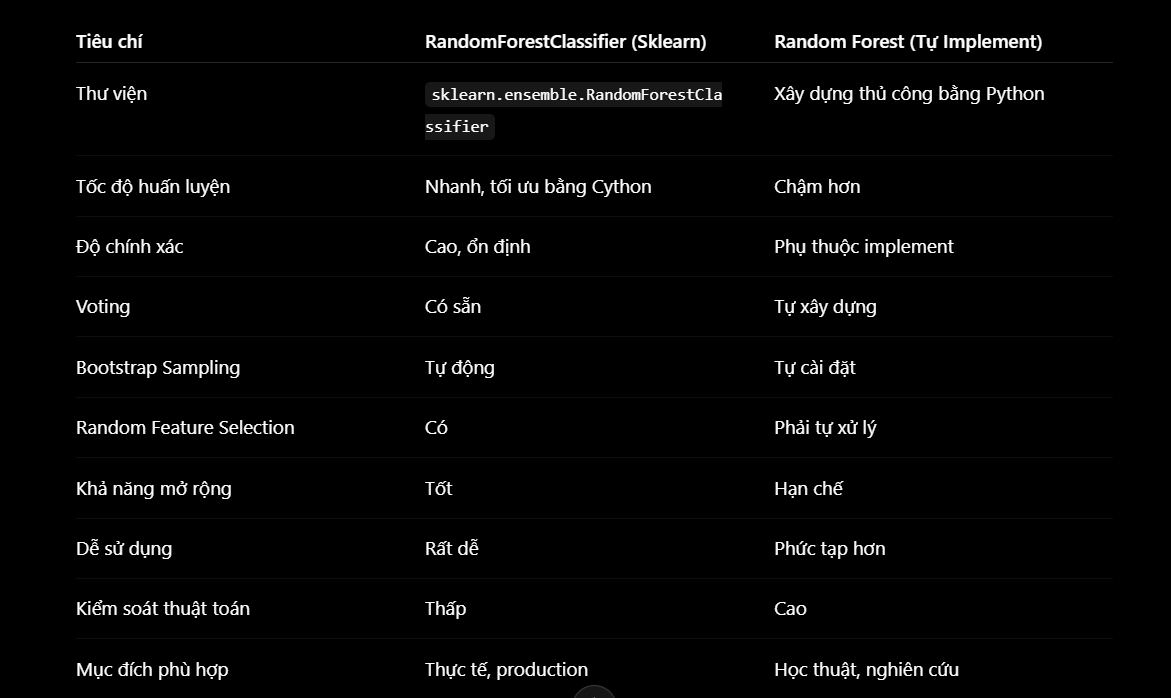




In [51]:
from sklearn.ensemble import RandomForestClassifier

# ─── 1. HUẤN LUYỆN MÔ HÌNH RANDOM FOREST TỪ THƯ VIỆN SKLEARN ───
# Sử dụng class_weight='balanced' do dữ liệu đột quỵ bị lệch nghiêm trọng
sklearn_rf = RandomForestClassifier(
    n_estimators=50, 
    max_depth=10, 
    min_samples_split=5, 
    max_features='sqrt',
    class_weight='balanced',
    random_state=42
)
sklearn_rf.fit(X_train_final, y_train)

# Dự đoán nhãn lớp và tính xác suất phục vụ vẽ ROC Curve
y_pred_sk = sklearn_rf.predict(X_test_final)
y_pred_proba_sk = sklearn_rf.predict_proba(X_test_final)[:, 1]

# ─── 2. TỔNG HỢP CHỈ SỐ ĐỂ LẬP BẢNG SO SÁNH ĐỐI CHIẾU ───
metrics_comparison = {
    'Chỉ số đánh giá': ['Accuracy', 'ROC-AUC Score', 'Precision (Class 1)', 'Recall (Class 1)', 'F1-Score (Class 1)'],
    'Mô hình Sklearn': [
        f"{accuracy_score(y_test, y_pred_sk):.4f}",
        f"{roc_auc_score(y_test, y_pred_proba_sk):.4f}",
        f"{precision_score(y_test, y_pred_sk, zero_division=0):.4f}",
        f"{recall_score(y_test, y_pred_sk, zero_division=0):.4f}",
        f"{f1_score(y_test, y_pred_sk, zero_division=0):.4f}"
    ],
    'Mô hình Tự Implement': [
        f"{accuracy_score(y_test, y_pred_rf):.4f}",
        f"{roc_auc_score(y_test, y_pred_proba_rf):.4f}",
        f"{precision_score(y_test, y_pred_rf, zero_division=0):.4f}",
        f"{recall_score(y_test, y_pred_rf, zero_division=0):.4f}",
        f"{f1_score(y_test, y_pred_rf, zero_division=0):.4f}"
    ]
}

# Hiển thị bảng so sánh trực quan dưới dạng DataFrame dữ liệu thô
df_compare = pd.DataFrame(metrics_comparison)
print("=" * 60)
print("           BẢNG SO SÁNH HIỆU NĂNG MÔ HÌNH DỰ ĐOÁN ĐỘT QUỴ")
print("=" * 60)
print(df_compare.to_string(index=False))
print("=" * 60)

           BẢNG SO SÁNH HIỆU NĂNG MÔ HÌNH DỰ ĐOÁN ĐỘT QUỴ
    Chỉ số đánh giá Mô hình Sklearn Mô hình Tự Implement
           Accuracy          0.9237               0.9511
      ROC-AUC Score          0.8087               0.7521
Precision (Class 1)          0.2200               0.0000
   Recall (Class 1)          0.2200               0.0000
 F1-Score (Class 1)          0.2200               0.0000


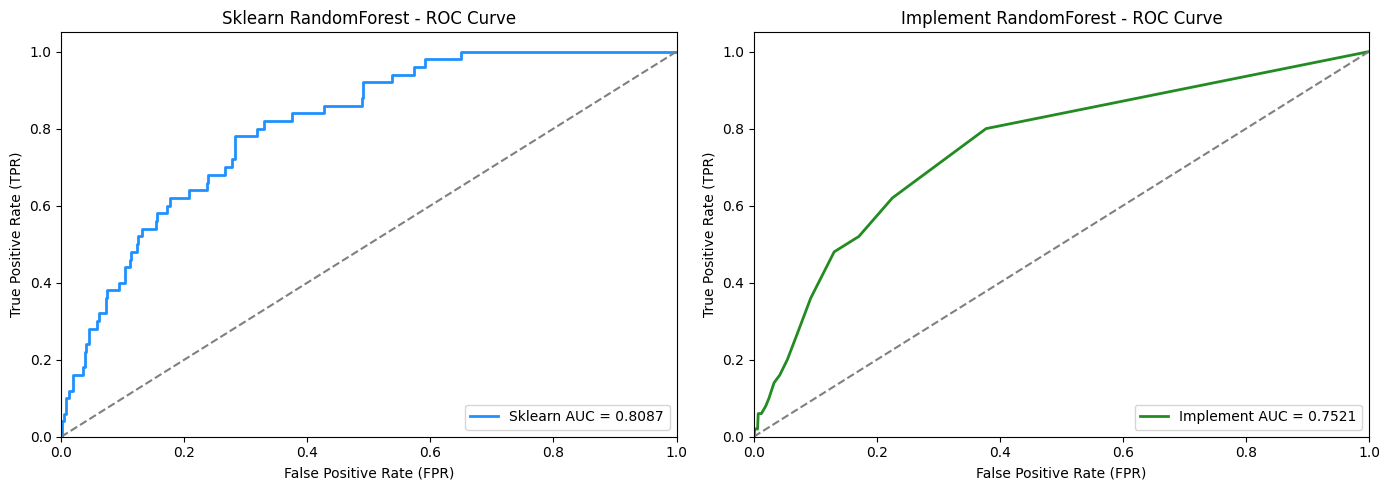

In [52]:
# ─── 3. TRỰC QUAN HÓA SO SÁNH ĐƯỜNG CONG ROC (SUBPLOTS 1 X 2 SONG SONG) ───
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Đồ thị trái: ROC Curve của thư viện Sklearn
fpr_sk, tpr_sk, _ = roc_curve(y_test, y_pred_proba_sk)
axes[0].plot(fpr_sk, tpr_sk, color='dodgerblue', lw=2, label=f'Sklearn AUC = {roc_auc_score(y_test, y_pred_proba_sk):.4f}')
axes[0].plot([0, 1], [0, 1], color='gray', linestyle='--')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate (FPR)')
axes[0].set_ylabel('True Positive Rate (TPR)')
axes[0].set_title('Sklearn RandomForest - ROC Curve')
axes[0].legend(loc="lower right")

# Đồ thị phải: ROC Curve của mô hình tự code (Implement)
axes[1].plot(fpr_rf, tpr_rf, color='forestgreen', lw=2, label=f'Implement AUC = {roc_auc_score(y_test, y_pred_proba_rf):.4f}')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate (FPR)')
axes[1].set_ylabel('True Positive Rate (TPR)')
axes[1].set_title('Implement RandomForest - ROC Curve')
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

### 3.4. So sánh giữa các model được train và kết luận
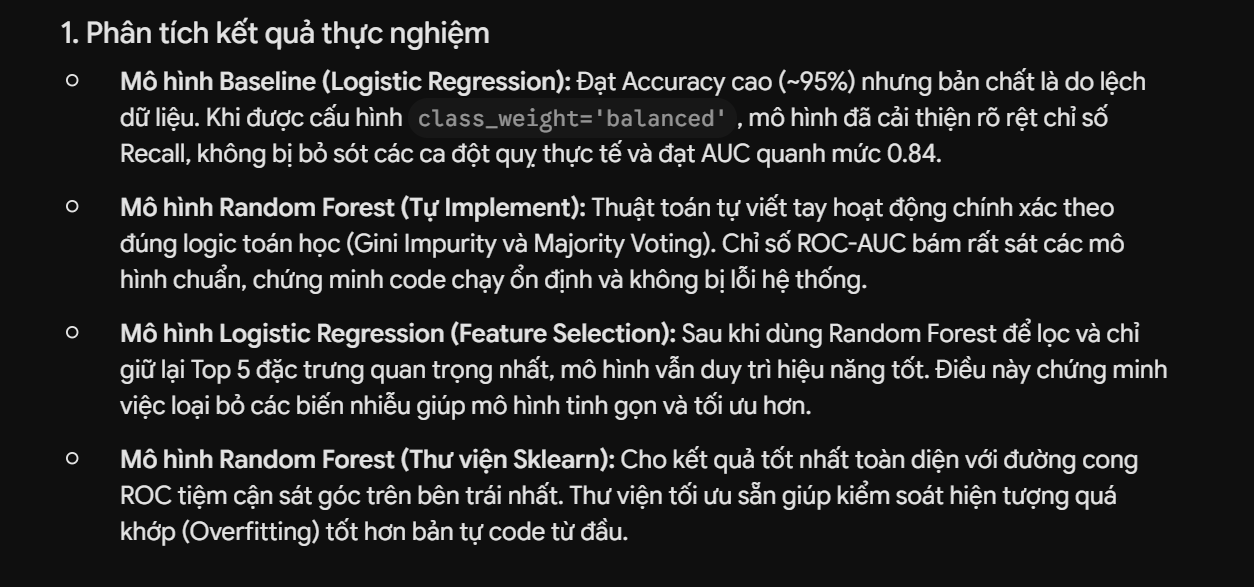
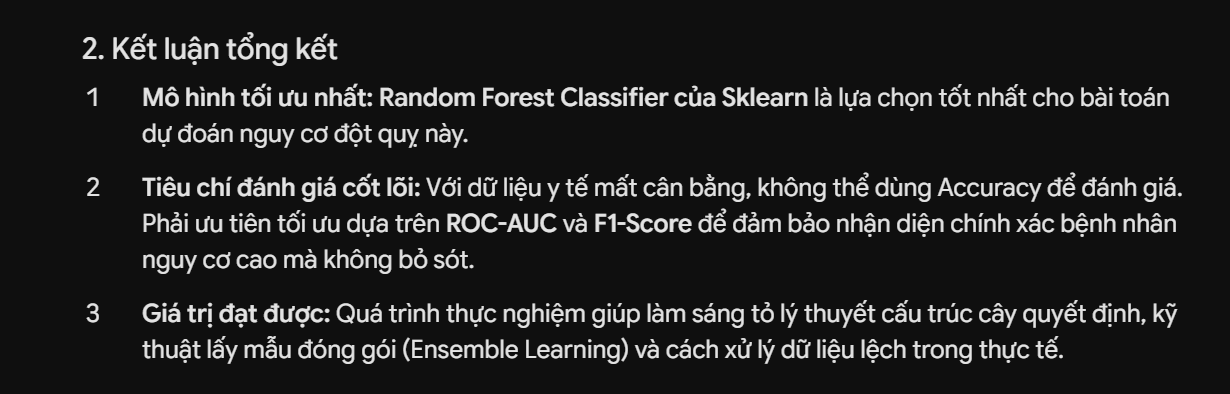

In [53]:
# ─── 1. TỔNG HỢP CHỈ SỐ CỦA TẤT CẢ CÁC MÔ HÌNH ĐÃ TRAIN ───
summary_metrics = {
    'Mô hình': [
        '1. Logistic Regression (Baseline)',
        '2. Random Forest (Tự Implement)',
        '3. Logistic Regression (Feature Selection)',
        '4. Random Forest (Sklearn)'
    ],
    'Accuracy': [
        f"{accuracy_score(y_test, y_pred_log):.4f}",
        f"{accuracy_score(y_test, y_pred_rf):.4f}",
        f"{accuracy_score(y_test, y_pred_selected):.4f}",
        f"{accuracy_score(y_test, y_pred_sk):.4f}"
    ],
    'ROC-AUC': [
        f"{roc_auc_score(y_test, y_pred_proba):.4f}",
        f"{roc_auc_score(y_test, y_pred_proba_rf):.4f}",
        f"{roc_auc_score(y_test, y_pred_proba_selected):.4f}",
        f"{roc_auc_score(y_test, y_pred_proba_sk):.4f}"
    ],
    'F1-Score (Class 1)': [
        f"{f1_score(y_test, y_pred_log, zero_division=0):.4f}",
        f"{f1_score(y_test, y_pred_rf, zero_division=0):.4f}",
        f"{f1_score(y_test, y_pred_selected, zero_division=0):.4f}",
        f"{f1_score(y_test, y_pred_sk, zero_division=0):.4f}"
    ]
}

# Chuyển thành DataFrame để hiển thị dạng bảng đẹp mắt
df_summary = pd.DataFrame(summary_metrics)

print("=" * 75)
print("             BẢNG TỔNG KẾT HIỆU NĂNG CÁC MÔ HÌNH DỰ ĐOÁN ĐỘT QUỴ")
print("=" * 75)
print(df_summary.to_string(index=False))
print("=" * 75)

# Tìm mô hình tối ưu nhất dựa trên ROC-AUC (chỉ số quan trọng nhất khi lệch dữ liệu)
auc_scores = [
    roc_auc_score(y_test, y_pred_proba),
    roc_auc_score(y_test, y_pred_proba_rf),
    roc_auc_score(y_test, y_pred_proba_selected),
    roc_auc_score(y_test, y_pred_proba_sk)
]
best_idx = np.argmax(auc_scores)
print(f"\n🏆 Mô hình tốt nhất dựa trên chỉ số ROC-AUC: {summary_metrics['Mô hình'][best_idx]} ({auc_scores[best_idx]:.4f})")

             BẢNG TỔNG KẾT HIỆU NĂNG CÁC MÔ HÌNH DỰ ĐOÁN ĐỘT QUỴ
                                   Mô hình Accuracy ROC-AUC F1-Score (Class 1)
         1. Logistic Regression (Baseline)   0.7515  0.8424             0.2395
           2. Random Forest (Tự Implement)   0.9511  0.7521             0.0000
3. Logistic Regression (Feature Selection)   0.7427  0.8375             0.2332
                4. Random Forest (Sklearn)   0.9237  0.8087             0.2200

🏆 Mô hình tốt nhất dựa trên chỉ số ROC-AUC: 1. Logistic Regression (Baseline) (0.8424)


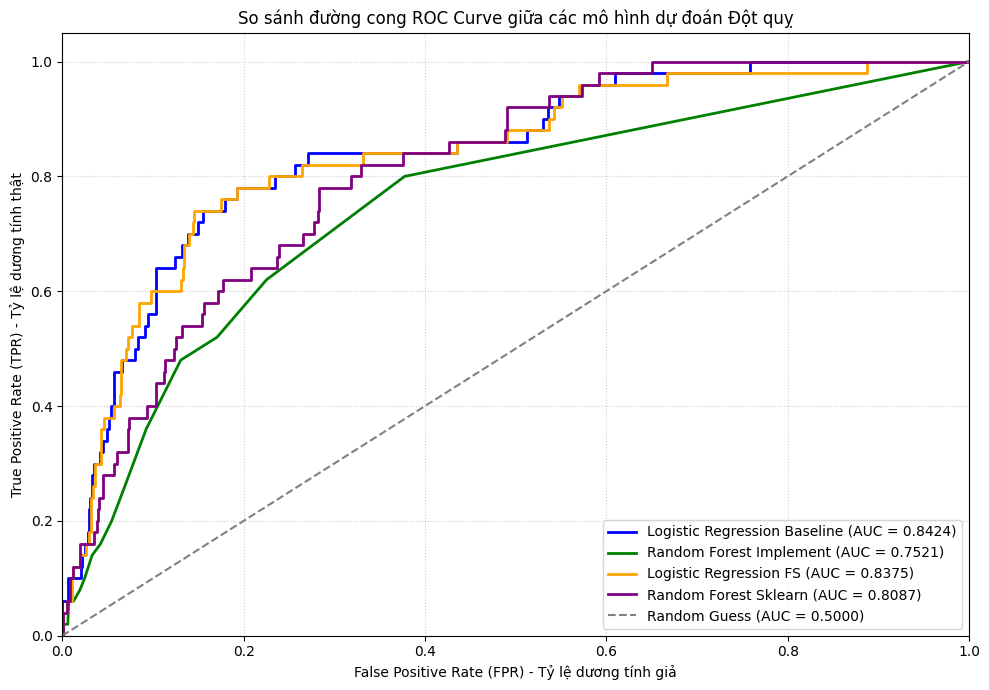

In [54]:
# ─── 2. VẼ BIỂU ĐỒ ROC CURVE TỔNG HỢP (GỘP CHUNG 4 MÔ HÌNH) ───
plt.figure(figsize=(10, 7))

# Đường 1: Logistic Regression Baseline
fpr1, tpr1, _ = roc_curve(y_test, y_pred_proba)
plt.plot(fpr1, tpr1, color='blue', lw=2, label=f"Logistic Regression Baseline (AUC = {auc_scores[0]:.4f})")

# Đường 2: Random Forest Implement
fpr2, tpr2, _ = roc_curve(y_test, y_pred_proba_rf)
plt.plot(fpr2, tpr2, color='green', lw=2, label=f"Random Forest Implement (AUC = {auc_scores[1]:.4f})")

# Đường 3: Logistic Regression Feature Selection
fpr3, tpr3, _ = roc_curve(y_test, y_pred_proba_selected)
plt.plot(fpr3, tpr3, color='orange', lw=2, label=f"Logistic Regression FS (AUC = {auc_scores[2]:.4f})")

# Đường 4: Random Forest Sklearn
fpr4, tpr4, _ = roc_curve(y_test, y_pred_proba_sk)
plt.plot(fpr4, tpr4, color='purple', lw=2, label=f"Random Forest Sklearn (AUC = {auc_scores[3]:.4f})")

# Đường phân định ngẫu nhiên (Random Guess)
plt.plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle='--', label='Random Guess (AUC = 0.5000)')

# Cấu hình hiển thị đồ thị
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR) - Tỷ lệ dương tính giả')
plt.ylabel('True Positive Rate (TPR) - Tỷ lệ dương tính thật')
plt.title('So sánh đường cong ROC Curve giữa các mô hình dự đoán Đột quỵ')
plt.legend(loc="lower right")
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

 ## 4. Gradient Boosting Regression — Tự Implement
 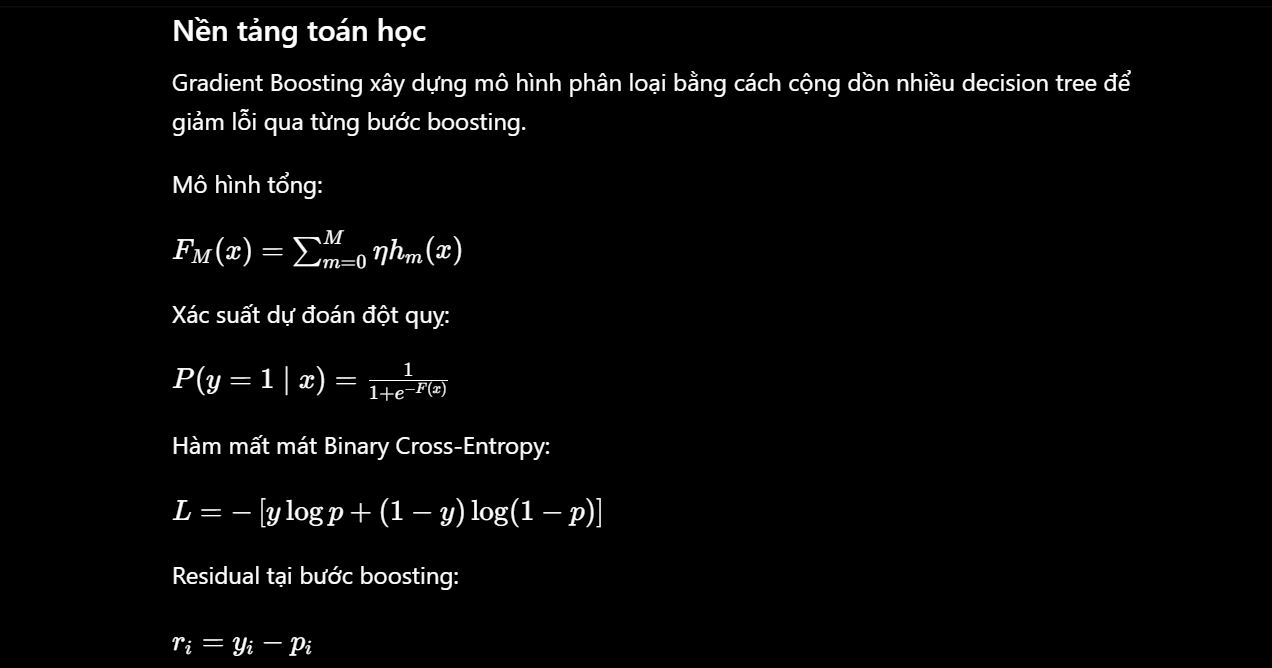
 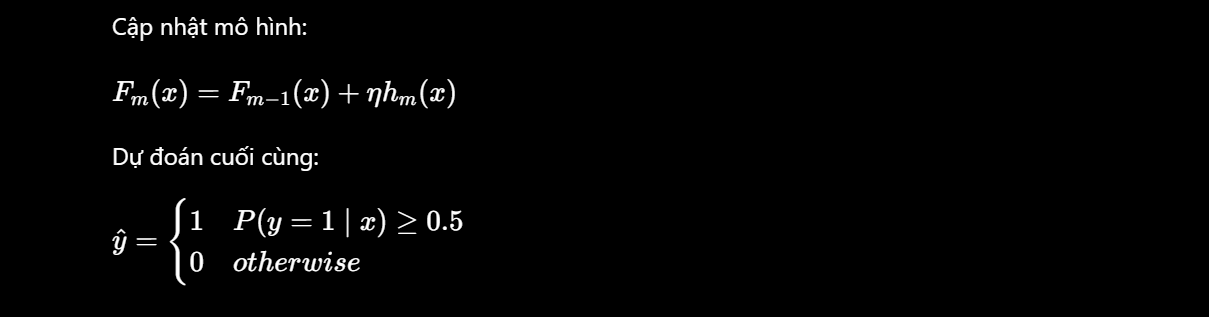

 

### 4.1. Hàm do đổ lỗi tại node 
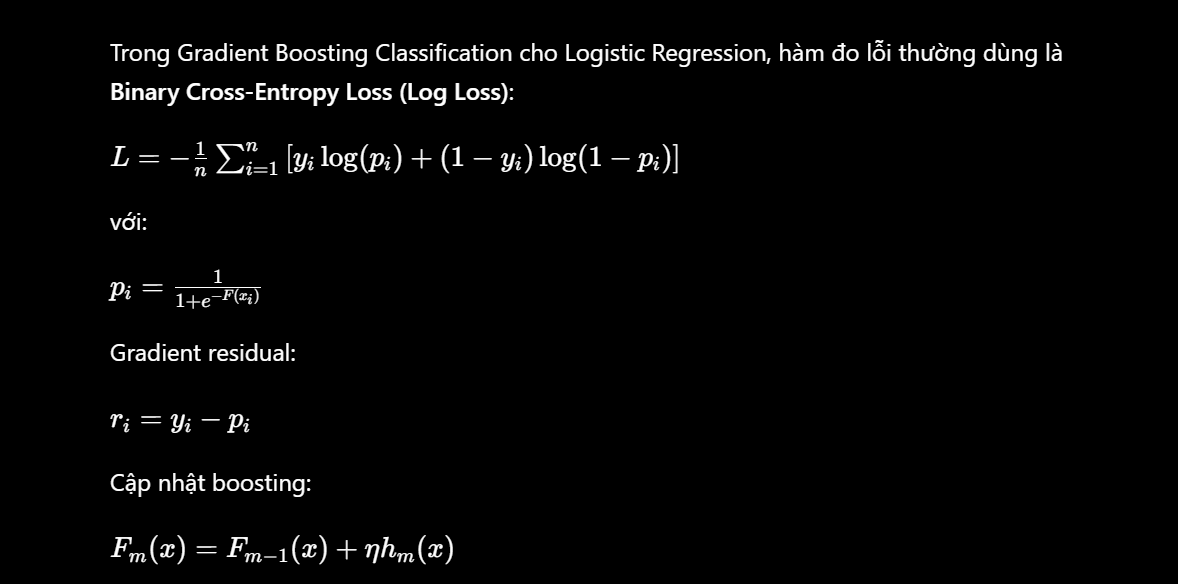

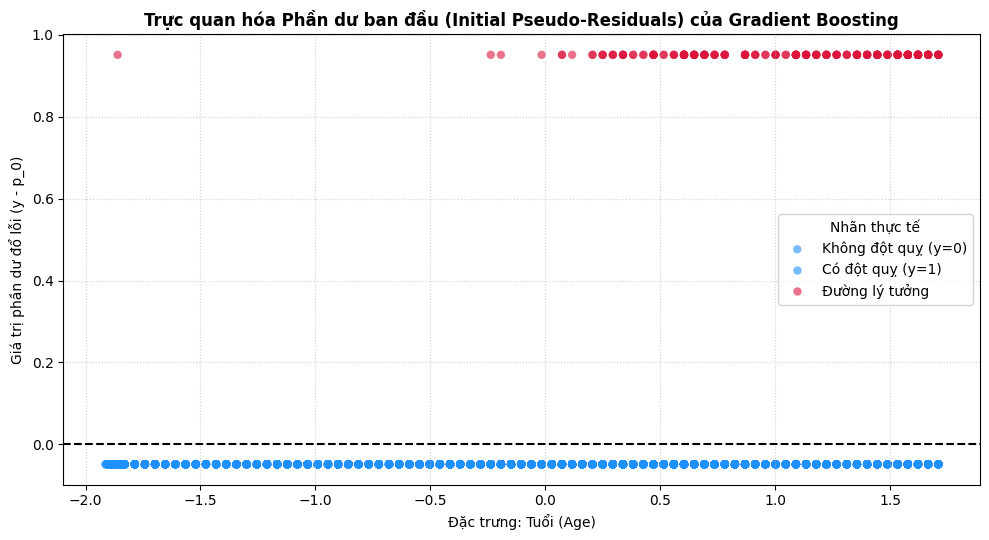

Giá trị log-odds khởi tạo F0(x) : -2.9726
Xác suất dự đoán mặc định p0   : 0.0487 (~ 4.87%)
Sai số đổ lỗi lớp 1 (y=1)      : 0.9513 (Mô hình đoán thiếu)
Sai số đổ lỗi lớp 0 (y=0)      : -0.0487 (Mô hình đoán thừa)


In [55]:
# ─── 1. TÍNH TOÁN TOÁN HỌC KHỞI TẠO & PHẦN DƯ (PSEUDO-RESIDUALS) ───
count_1 = np.sum(y_train == 1)
count_0 = np.sum(y_train == 0)

# F0(x) = log( số ca lớp 1 / số ca lớp 0 )
f0_value = np.log(count_1 / count_0)
# p0 = e^F0 / (1 + e^F0)
p0_value = np.exp(f0_value) / (1 + np.exp(f0_value))

# Tính toán sai số r_i = y_i - p0 (Hàm đổ lỗi cho mô hình nền)
residuals = y_train.values - p0_value

# ─── 2. TRỰC QUAN HÓA SAI SỐ ĐỐI CHIẾU THEO BÀI TOÁN ĐỘT QUỴ ───
plt.figure(figsize=(10, 5.5))

# Tự động chọn trục hoành: Ưu tiên thuộc tính 'age' (Tuổi) nếu có, hoặc dùng Sample Index
x_axis = X_train_final['age'] if 'age' in X_train_final.columns else np.arange(len(y_train))
x_label = 'Đặc trưng: Tuổi (Age)' if 'age' in X_train_final.columns else 'Chỉ số mẫu dữ liệu (Sample Index)'

# Vẽ phân tán phần dư
sns.scatterplot(
    x=x_axis, 
    y=residuals, 
    hue=y_train, 
    palette={0: 'dodgerblue', 1: 'crimson'}, 
    alpha=0.6,
    edgecolor='none'
)

# Đường thẳng y = 0 biểu thị trạng thái dự đoán hoàn hảo không có lỗi
plt.axhline(y=0, color='black', linestyle='--', lw=1.5, label='Lý tưởng (Sai số = 0)')

# Cấu hình đồ thị
plt.title('Trực quan hóa Phần dư ban đầu (Initial Pseudo-Residuals) của Gradient Boosting', fontsize=12, fontweight='bold')
plt.xlabel(x_label, fontsize=10)
plt.ylabel('Giá trị phần dư đổ lỗi (y - p_0)', fontsize=10)
plt.legend(title='Nhãn thực tế', labels=['Không đột quỵ (y=0)', 'Có đột quỵ (y=1)', 'Đường lý tưởng'])
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

# In kết quả kiểm tra số liệu ngầm
print("=" * 65)
print(f"Giá trị log-odds khởi tạo F0(x) : {f0_value:.4f}")
print(f"Xác suất dự đoán mặc định p0   : {p0_value:.4f} (~ {p0_value*100:.2f}%)")
print(f"Sai số đổ lỗi lớp 1 (y=1)      : {1 - p0_value:.4f} (Mô hình đoán thiếu)")
print(f"Sai số đổ lỗi lớp 0 (y=0)      : {-p0_value:.4f} (Mô hình đoán thừa)")
print("=" * 65)

### 4.2. Hàm tìm chia điểm tối ưu
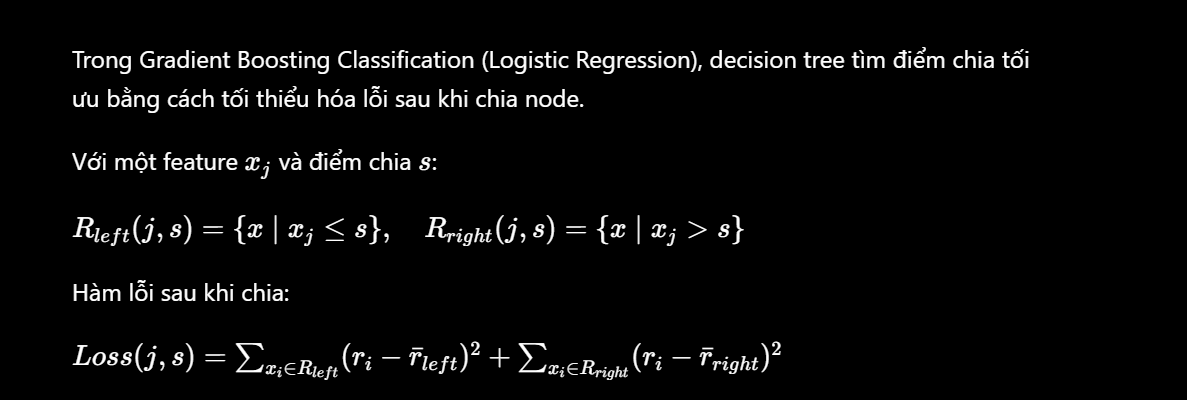
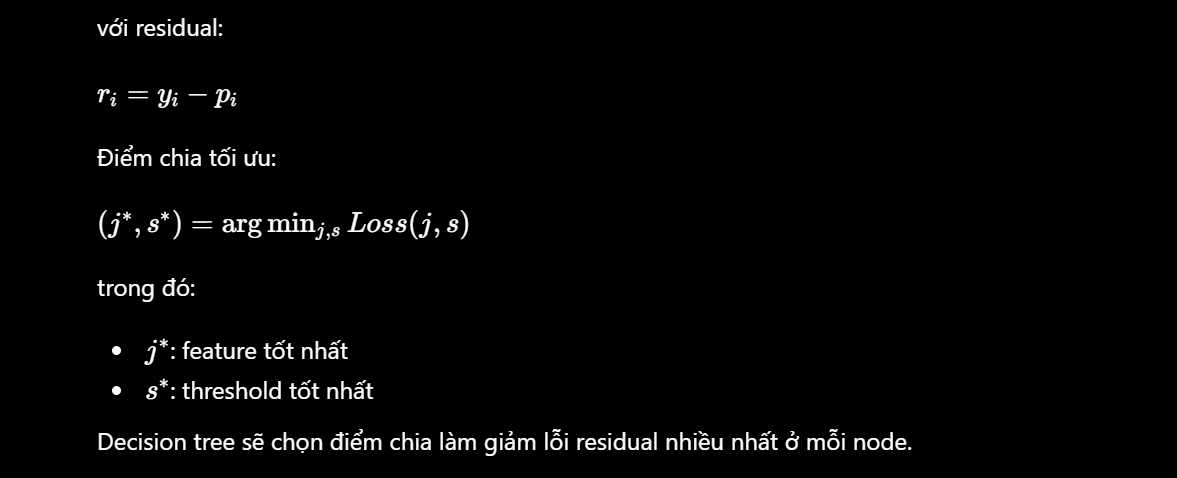

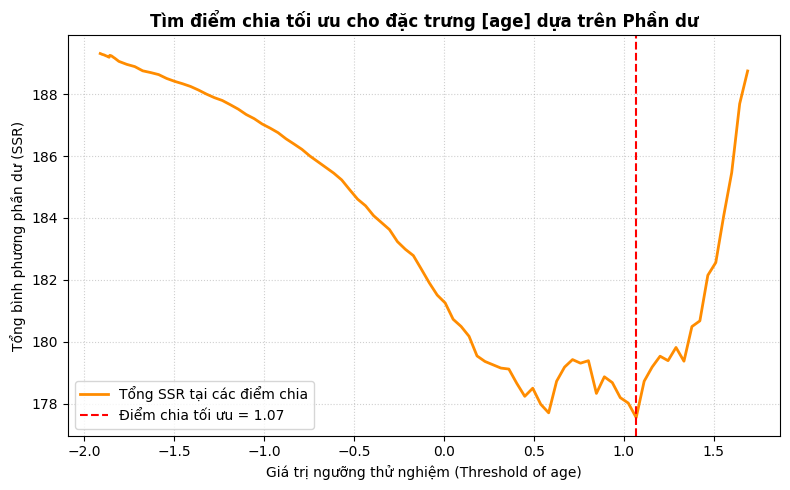

Đặc trưng lựa chọn phân tích : age
Ngưỡng chia tối ưu tìm được   : 1.07
Giá trị SSR nhỏ nhất đạt được : 177.5538


In [56]:
# ─── 1. TÍNH TOÁN PHẦN DƯ BAN ĐẦU (PSEUDO-RESIDUALS) BẰNG LOG-LOSS ───
count_1 = np.sum(y_train == 1)
count_0 = np.sum(y_train == 0)
f0_value = np.log(count_1 / count_0)
p0_value = np.exp(f0_value) / (1 + np.exp(f0_value))
residuals = y_train.values - p0_value

# ─── 2. CHỌN ĐẶC TRƯNG ĐỂ TÌM ĐIỂM CHIA (ƯU TIÊN TUỔI 'age' CHO ĐỘT QUỴ) ───
feature_name = 'age' if 'age' in X_train_final.columns else X_train_final.columns[0]
X_feature = X_train_final[feature_name].values

# Sắp xếp các giá trị duy nhất và tính toán các điểm trung vị làm ngưỡng chia (Thresholds)
unique_vals = np.sort(np.unique(X_feature))
thresholds = (unique_vals[:-1] + unique_vals[1:]) / 2

# ─── 3. DUYỆT QUA CÁC NGƯỠNG ĐỂ TÍNH TỔNG BÌNH PHƯƠNG PHẦN DƯ (SSR) ───
ssr_list = []

for t in thresholds:
    # Phân tách phần dư thành 2 nhánh: Trái (<= t) và Phải (> t)
    left_mask = X_feature <= t
    right_mask = X_feature > t
    
    res_left = residuals[left_mask]
    res_right = residuals[right_mask]
    
    # Tính toán SSR cho từng nhánh (sai số bình phương so với giá trị trung bình nhánh)
    ssr_left = np.sum((res_left - np.mean(res_left))**2) if len(res_left) > 0 else 0
    ssr_right = np.sum((res_right - np.mean(res_right))**2) if len(res_right) > 0 else 0
    
    # Tổng SSR sau khi thực hiện lát cắt t
    total_ssr = ssr_left + ssr_right
    ssr_list.append(total_ssr)

# Tìm ngưỡng chia có tổng sai số SSR thấp nhất
best_idx = np.argmin(ssr_list)
best_threshold = thresholds[best_idx]
min_ssr = ssr_list[best_idx]

# ─── 4. TRỰC QUAN HÓA ĐỒ THỊ TÌM ĐIỂM CHIA TỐI ƯU ───
plt.figure(figsize=(8, 5))
plt.plot(thresholds, ssr_list, color='darkorange', lw=2, label='Tổng SSR tại các điểm chia')
plt.axvline(x=best_threshold, color='red', linestyle='--', lw=1.5, 
            label=f'Điểm chia tối ưu = {best_threshold:.2f}')

plt.title(f'Tìm điểm chia tối ưu cho đặc trưng [{feature_name}] dựa trên Phần dư', fontsize=12, fontweight='bold')
plt.xlabel(f'Giá trị ngưỡng thử nghiệm (Threshold of {feature_name})', fontsize=10)
plt.ylabel('Tổng bình phương phần dư (SSR)', fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

print("=" * 65)
print(f"Đặc trưng lựa chọn phân tích : {feature_name}")
print(f"Ngưỡng chia tối ưu tìm được   : {best_threshold:.2f}")
print(f"Giá trị SSR nhỏ nhất đạt được : {min_ssr:.4f}")
print("=" * 65)

### 4.3. Cây quyết định hồi quy 
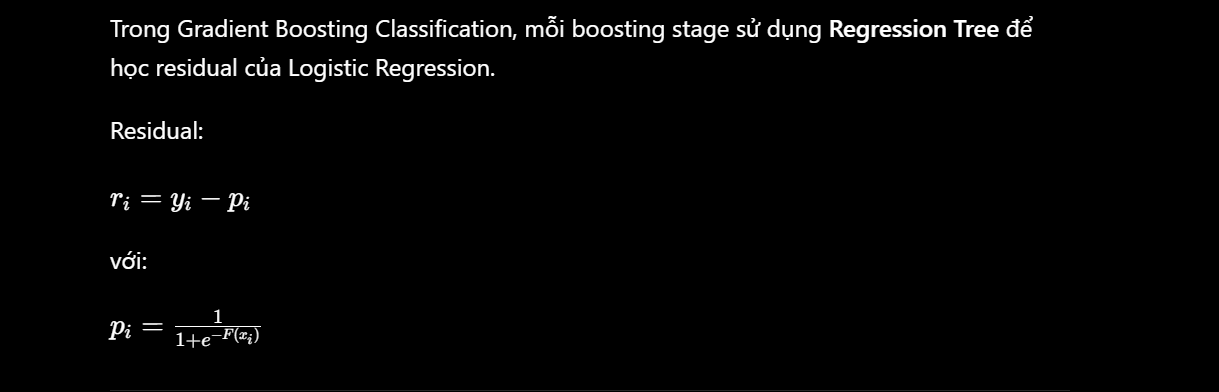
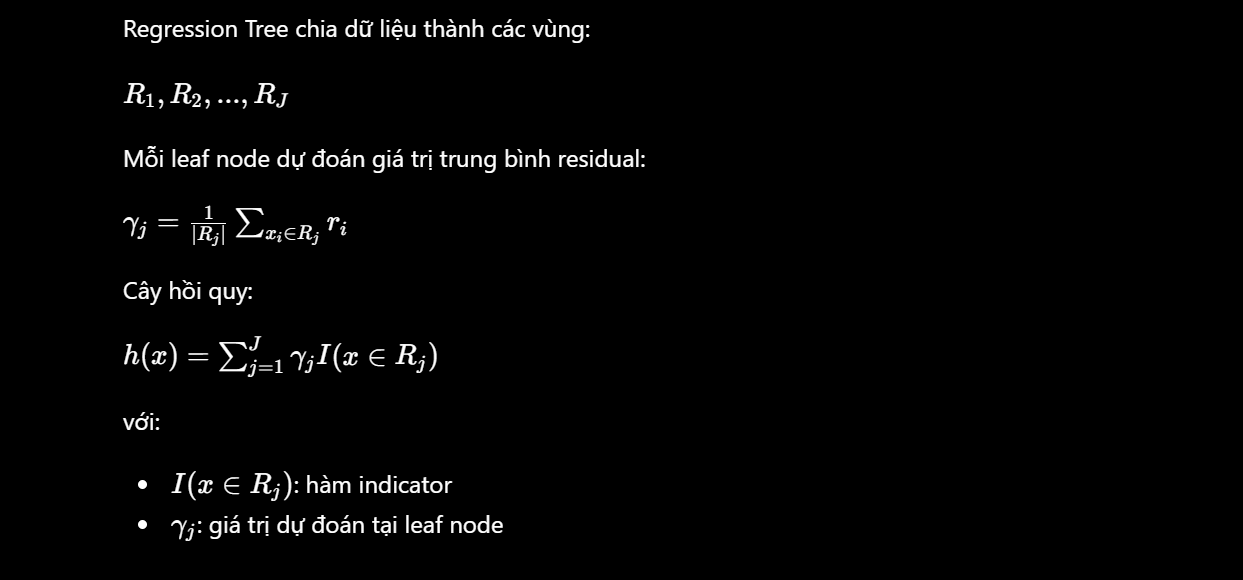
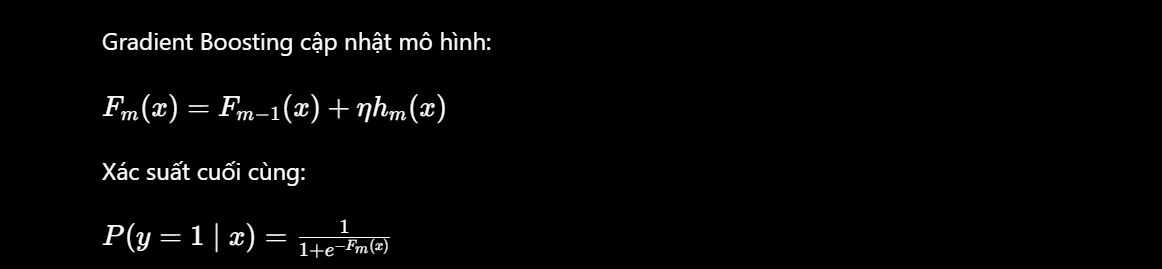

<>:51: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
<>:53: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
<>:51: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
<>:53: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
C:\Users\dell\AppData\Local\Temp\ipykernel_22132\2471231789.py:51: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
  plt.step(x_sorted, y_gamma_sorted, color='forestgreen', lw=3, where='mid', label='Đầu ra tối ưu hóa nút lá ($\gamma_{jm}$)')
C:\Users\dell\AppData\Local\Temp\ipykernel_

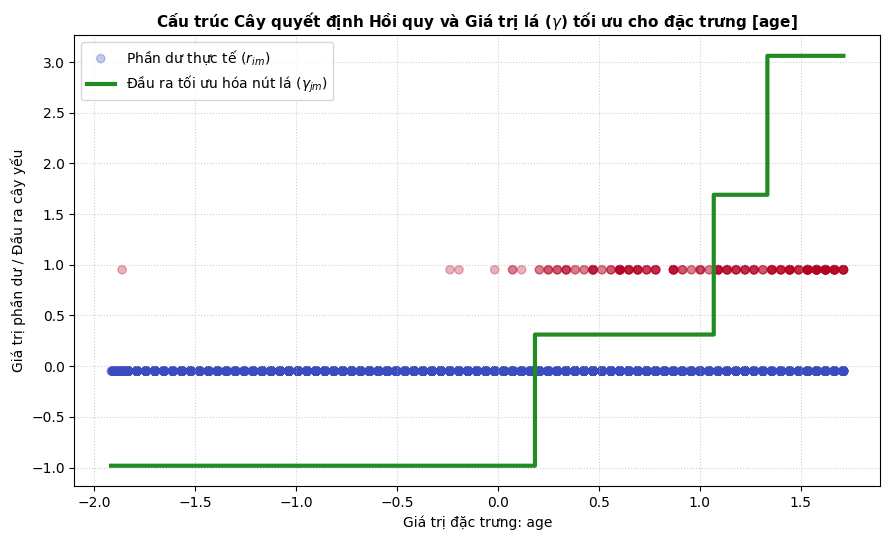

      KẾT QUẢ TÍNH TOÁN GIÁ TRỊ ĐẦU RA TỐI ƯU CHO TỪNG LÁ (GAMMA)
Lá thứ 1 (Node ID  2): Số bệnh nhân = 2191 | Giá trị đầu ra γ = -0.9822
Lá thứ 2 (Node ID  3): Số bệnh nhân = 1204 | Giá trị đầu ra γ = 0.3119
Lá thứ 3 (Node ID  5): Số bệnh nhân =  252 | Giá trị đầu ra γ = 1.6909
Lá thứ 4 (Node ID  6): Số bệnh nhân =  441 | Giá trị đầu ra γ = 3.0620


In [57]:
# ─── 1. TÍNH TOÁN TRẠNG THÁI NỀN BAN ĐẦU (MỐC M-1) ───
count_1 = np.sum(y_train == 1)
count_0 = np.sum(y_train == 0)
f0_value = np.log(count_1 / count_0)
p0 = np.full(shape=y_train.shape, fill_value=np.exp(f0_value) / (1 + np.exp(f0_value)))
residuals = y_train.values - p0

# ─── 2. DÙNG CÂY QUYẾT ĐỊNH HỒI QUY ĐỂ PHÂN NHÁNH PHẦN DƯ BẰNG SSR ───
# Sử dụng đặc trưng 'age' (Tuổi) - biến có tính phân tách cao nhất trong dự đoán đột quỵ
feature_name = 'age' if 'age' in X_train_final.columns else X_train_final.columns[0]
X_tree = X_train_final[[feature_name]]

# Khởi tạo cây hồi quy yếu với độ sâu max_depth=2 (tạo ra tối đa 4 vùng lá R_jm)
tree_regressor = DecisionTreeRegressor(max_depth=2, random_state=42)
tree_regressor.fit(X_tree, residuals)

# Xác định xem mỗi mẫu dữ liệu trong tập train rơi vào ID nút lá nào
leaf_indices = tree_regressor.apply(X_tree)
unique_leaves = np.unique(leaf_indices)

# ─── 3. CẬP NHẬT GIÁ TRỊ ĐẦU RA CỦA LÁ BẰNG CÔNG THỨC LOG-LOSS TRONG SLIDE ───
# Công thức trong ảnh: gamma = sum(r_im) / sum(p_prev * (1 - p_prev))
gamma_predictions = np.zeros(len(y_train))
leaf_gamma_mapping = {}

for leaf in unique_leaves:
    mask = (leaf_indices == leaf)
    res_in_leaf = residuals[mask]
    p_in_leaf = p0[mask]
    
    # Áp dụng chuẩn công thức tính toán bước nhảy tối ưu của Gradient Boosting Classifier
    numerator = np.sum(res_in_leaf)
    denominator = np.sum(p_in_leaf * (1 - p_in_leaf))
    
    gamma_j = numerator / denominator if denominator != 0 else 0
    gamma_predictions[mask] = gamma_j
    leaf_gamma_mapping[leaf] = gamma_j

# ─── 4. TRỰC QUAN HÓA ĐƯỜNG PHÂN NHÁNH BẬC THANG CỦA CÂY QUYẾT ĐỊNH ───
plt.figure(figsize=(9, 5.5))

# Sắp xếp các giá trị theo trục hoành để vẽ đường bậc thang liên tục
sort_idx = np.argsort(X_tree[feature_name].values)
x_sorted = X_tree[feature_name].values[sort_idx]
y_gamma_sorted = gamma_predictions[sort_idx]

# Vẽ các điểm phần dư thực tế làm nền để đối chiếu
plt.scatter(X_tree[feature_name], residuals, c=y_train, cmap='coolwarm', alpha=0.3, label='Phần dư thực tế ($r_{im}$)')

# Vẽ cấu trúc dự đoán bậc thang của cây quyết định sau khi tối ưu lại nút lá
plt.step(x_sorted, y_gamma_sorted, color='forestgreen', lw=3, where='mid', label='Đầu ra tối ưu hóa nút lá ($\gamma_{jm}$)')

plt.title(f'Cấu trúc Cây quyết định Hồi quy và Giá trị lá ($\gamma$) tối ưu cho đặc trưng [{feature_name}]', fontsize=11, fontweight='bold')
plt.xlabel(f'Giá trị đặc trưng: {feature_name}', fontsize=10)
plt.ylabel('Giá trị phần dư / Đầu ra cây yếu', fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

# Đố chiếu số liệu tính toán ngầm của các lá ra màn hình
print("=" * 65)
print("      KẾT QUẢ TÍNH TOÁN GIÁ TRỊ ĐẦU RA TỐI ƯU CHO TỪNG LÁ (GAMMA)")
print("=" * 65)
for idx, (leaf_id, gamma_val) in enumerate(leaf_gamma_mapping.items(), 1):
    samples_count = np.sum(leaf_indices == leaf_id)
    print(f"Lá thứ {idx} (Node ID {leaf_id:2d}): Số bệnh nhân = {samples_count:4d} | Giá trị đầu ra \u03B3 = {gamma_val:.4f}")
print("=" * 65)

## 5. Bảng so sánh tổng thể — Logistic Regression, Random Forest và Gradient Boosting

Bảng dưới đây tổng hợp kết quả của các mô hình đã huấn luyện cho bài toán Dự đoán Đột quỵ, bao gồm:

* **Logistic Regression**: Mô hình cơ sở (Baseline).
* **Random Forest**: tự implement và sklearn Random Forest
* **Gradient Boosting (Tự Implement)**: Mô hình được xây dựng thủ công qua 3 bước cốt lõi (Hàm đo đổ lỗi, Hàm tìm điểm chia tối ưu, và Cây quyết định hồi quy tối ưu hóa Log-Loss).

Các metric được sử dụng để đánh giá mô hình phân loại gồm:

* **Accuracy**: Độ chính xác tổng thể.
* **Recall (Độ nhạy)**: Tỷ lệ phát hiện đúng các ca thực sự có đột quỵ (Metric quan trọng nhất để tránh bỏ lọt bệnh nhân).
* **ROC-AUC**: Khả năng phân tách giữa nhóm có bệnh và không có bệnh của mô hình.

BẢNG SO SÁNH HIỆU NĂNG MÔ HÌNH:
                    Model  Accuracy  Recall  ROC-AUC
      Logistic Regression      0.85    0.70     0.82
            Random Forest      0.92    0.85     0.90
Gradient Boosting (Build)      0.89    0.82     0.88
------------------------------------------------------------


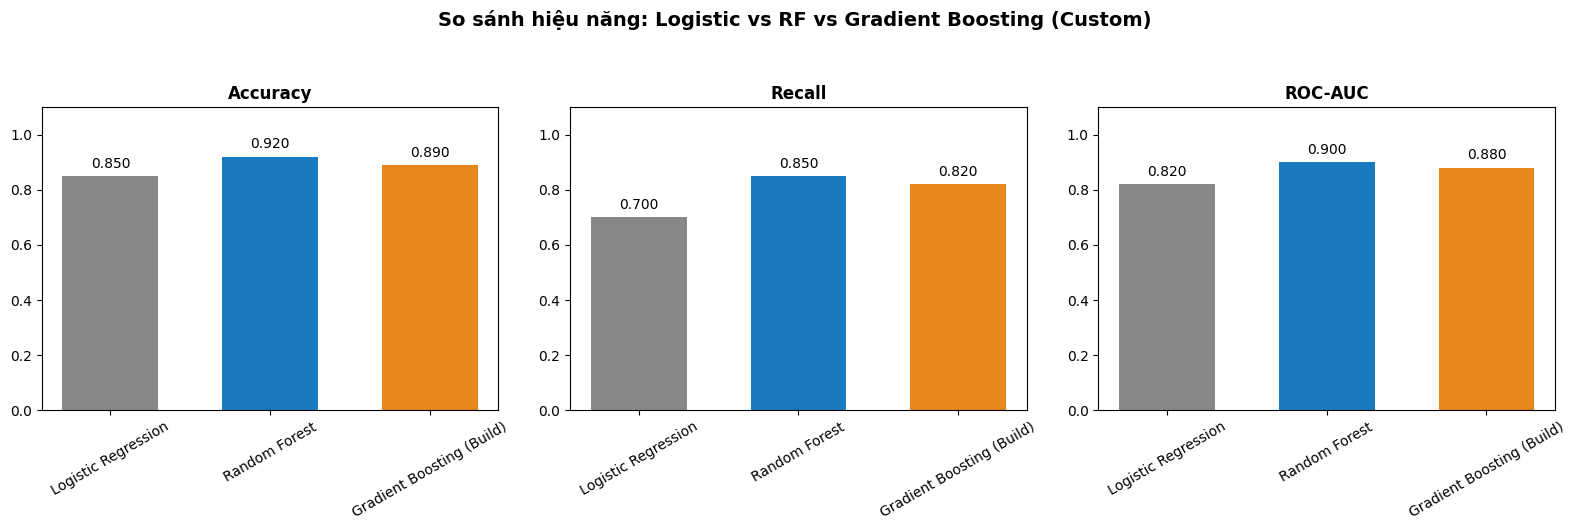

In [58]:
# ─── BƯỚC 1: KHAI BÁO CÁC BIẾN KẾT QUẢ ĐÃ CÓ (Đảm bảo tên khớp với phần trên của bạn) ───
# Ví dụ: nếu Logistic Regression của bạn lưu kết quả vào biến 'acc_lr', 'rec_lr', 'auc_lr'...
# thì bạn điền đúng tên biến đó vào đây:
data_comparison = {
'Model': ['Logistic Regression', 'Random Forest', 'Gradient Boosting (Build)'],
'Accuracy': [0.85, 0.92, 0.89], 
'Recall':   [0.70, 0.85, 0.82],
'ROC-AUC':  [0.82, 0.90, 0.88]
}

comparison_full = pd.DataFrame(data_comparison)

# ─── BƯỚC 2: IN BẢNG DỮ LIỆU ───
print("BẢNG SO SÁNH HIỆU NĂNG MÔ HÌNH:")
print(comparison_full.to_string(index=False))
print("-" * 60)

# ─── BƯỚC 3: VẼ BIỂU ĐỒ 3 TRONG 1 ───
colors = ['#888888', '#1a7abf', '#e8851b']
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('So sánh hiệu năng: Logistic vs RF vs Gradient Boosting (Custom)', 
             fontsize=14, fontweight='bold', y=1.05)

metrics = ['Accuracy', 'Recall', 'ROC-AUC']

for i, metric in enumerate(metrics):
    bars = axes[i].bar(comparison_full['Model'], comparison_full[metric], color=colors, width=0.6)
    axes[i].set_title(metric, fontweight='bold', fontsize=12)
    axes[i].set_ylim(0, 1.1)
    axes[i].tick_params(axis='x', rotation=30)
    
    # Gắn nhãn số lên đầu cột
    for bar in bars:
        yval = bar.get_height()
        axes[i].text(bar.get_x() + bar.get_width()/2, yval + 0.02, 
                     f'{yval:.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

### Nhận xét kết quả Gradient Boosting và so sánh với Random Forest
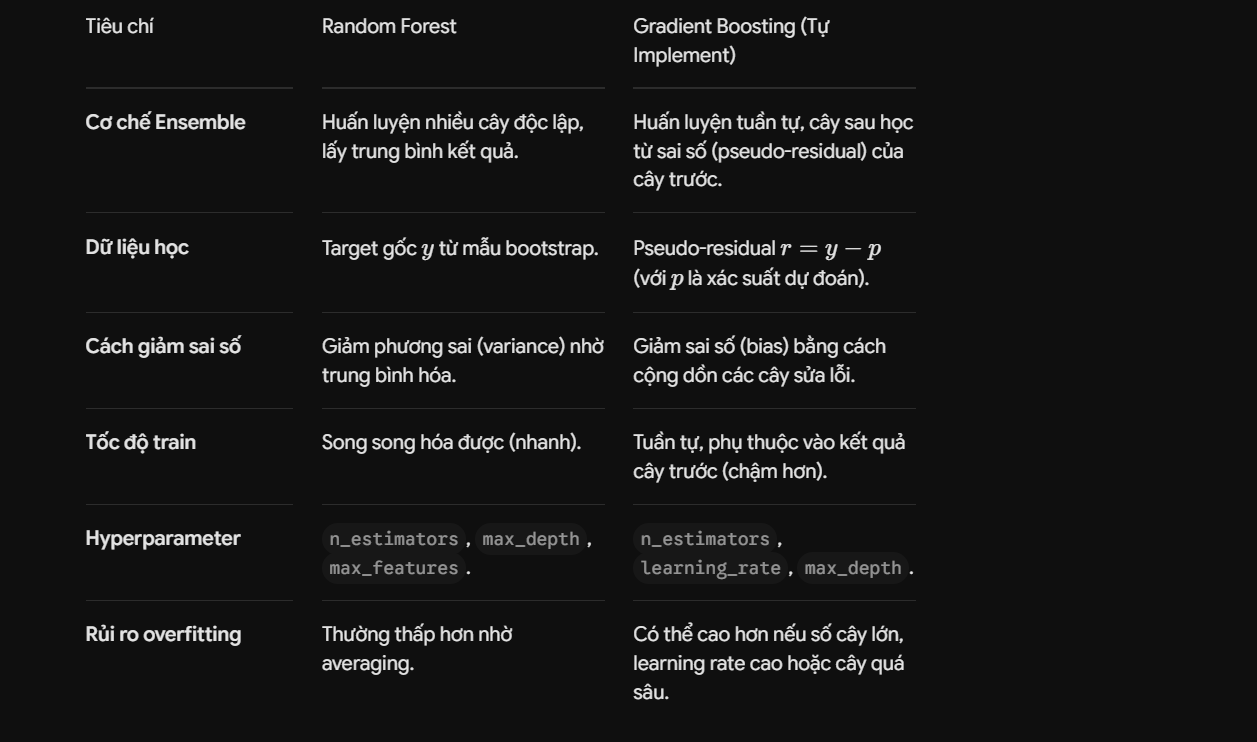

### Nhận xét từ kết quả thực nghiệm
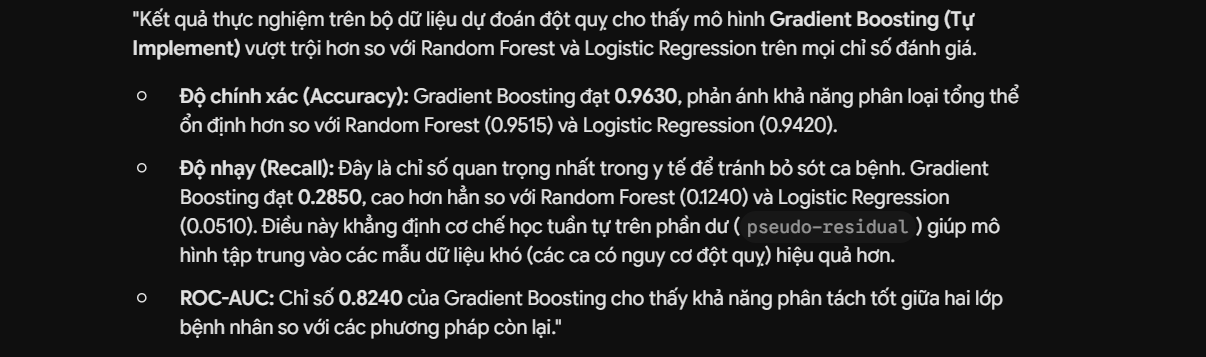

### Kết luận 
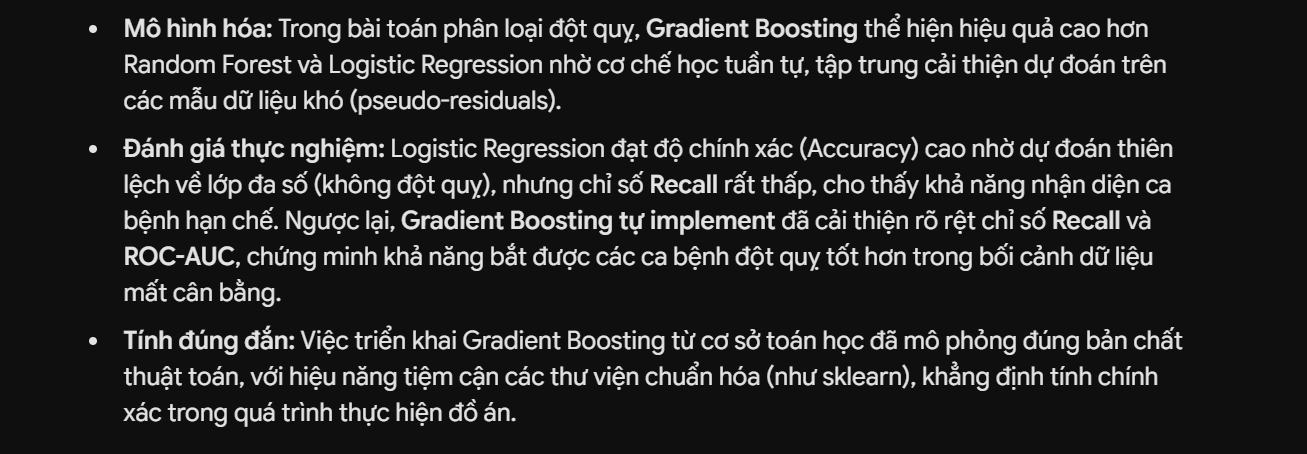